# Setup

In [1]:

import torch
import torch.onnx

# Mock the missing attribute if it doesn't exist\n",
if not hasattr(torch.onnx, '_CAFFE2_ATEN_FALLBACK'):
    torch.onnx._CAFFE2_ATEN_FALLBACK = False

import torchvision.io
import sys

# Monkey patch torchvision.io to add VideoReader\n",
if not hasattr(torchvision.io, 'VideoReader'):
    class VideoReaderStub:
        def __init__(self, *args, **kwargs):
            raise ImportError(
                "VideoReader is not available in this torchvision version."
            )
    torchvision.io.VideoReader = VideoReaderStub

print("✓ Applied torchvision VideoReader patch")

✓ Applied torchvision VideoReader patch


In [2]:
!pip install pyswarms
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 6.3 MB/s eta 0:00:00


# Foundations

## Mathematical Formulation of the Optimization Problem

### 1. Problem Formulation (HPO as an Optimization Problem)

The core objective of this notebook is to solve a **Hyperparameter Optimization (HPO)** problem. This is not a standard optimization over a continuous vector space, but an optimization over the configuration space of a machine learning model’s hyperparameters. We can formulate it as follows:

Let $\mathcal{M}(x; \theta)$ be the DistilBERT model with fixed architecture and trainable parameters $\theta$. Let $D_{\text{train}}$, $D_{\text{val}}$, and $D_{\text{test}}$ be the training, validation, and test splits of the IMDB dataset.

We define a hyperparameter configuration as a vector $\lambda$ in a bounded search space $\Lambda$:

$$
\lambda = [\lambda_1, \lambda_2, \lambda_3, \lambda_4, \lambda_5]^T \in \Lambda
$$

where:
- $\lambda_1 = lr \in [5\times10^{-6}, 5\times10^{-5}] \subset \mathbb{R}_{\ge 0}$ (learning rate, continuous, log scale)
- $\lambda_2 = e \in \{3, 4, 5, 6, 7\} \subset \mathbb{N}$ (number of epochs, integer, discrete)
- $\lambda_3 = wd \in [1\times10^{-5}, 5\times10^{-2}] \subset \mathbb{R}_{\ge 0}$ (weight decay, continuous, log scale)
- $\lambda_4 = wu \in [0.0, 0.5] \subset \mathbb{R}_{\ge 0}$ (warmup ratio, continuous)
- $\lambda_5 = dr \in [0.05, 0.30] \subset \mathbb{R}_{\ge 0}$ (dropout rate, continuous)

The objective of HPO is to find the hyperparameter configuration $\lambda^*$ that minimizes a validation loss function $L$, which measures the performance of a model trained with those hyperparameters.

Let $\mathcal{T}(D_{\text{train}}, \lambda) = \theta^*$ be the **training procedure** that returns the optimal model parameters $\theta^*$ after training the model on $D_{\text{train}}$ using hyperparameters $\lambda$. This procedure is deterministic and computationally expensive. The validation loss for a configuration $\lambda$ is then defined as:

$$
f(\lambda) = L\left( \mathcal{M}(\cdot; \mathcal{T}(D_{\text{train}}, \lambda)), \; D_{\text{val}} \right)
$$

where $L(\cdot)$ computes the cross-entropy loss on the validation set $D_{\text{val}}$.

The **Hyperparameter Optimization problem** is then defined as:

$$
\lambda^* = \underset{\lambda \in \Lambda}{\arg\min} \; f(\lambda)
$$

This is our target problem: a noisy, expensive-to-evaluate, black-box optimization problem over a mixed continuous-discrete, bounded search space.

### 2. Why this is NOT a Classical Optimization Problem

The above formulation reveals why our problem fundamentally differs from standard optimization categories. Let's examine why it does not fit into the following classical paradigms:

| Optimization Category | Why Our HPO Problem is NOT of this Type |
| :--- | :--- |
| **Linear Programming (LP)** | The objective function $f(\lambda)$ is **not linear**. The relationship between hyperparameters (e.g., learning rate) and final validation loss is highly non-linear, exhibiting convex and non-convex behavior, plateaus, and sharp cliffs. Constraints are simple box bounds, not linear inequalities, and the cost function is not representable as $c^T \lambda$. |
| **Integer / Binary Linear Programming (ILP / BLP)** | While $\lambda_2$ (epochs) is an integer, the objective function is still non-linear. ILP and BLP rely on linear objectives with integer constraints, solvable via branch-and-bound or cutting-plane methods. Our objective function has no closed mathematical form and cannot be expressed as a linear combination of variables. The existence of non-linear and continuous variables further disqualifies it. |
| **Quadratic Programming (QP)** | $f(\lambda)$ is not a quadratic function of the hyperparameters. It cannot be expressed in the form $\frac{1}{2}\lambda^T Q \lambda + c^T \lambda$. The interaction between hyperparameters (e.g., learning rate and weight decay) is highly complex, not a simple quadratic pairing. |
| **Convex Optimization** | The optimization landscape of $f(\lambda)$ is demonstrably **non-convex**. There is no guarantee that a local minimum is a global one. Different starting points lead to different final configurations, a hallmark of non-convexity. Convex optimization algorithms (e.g., gradient descent on a convex function) guarantee global optimality, which is impossible here. |
| **Gradient-Based Optimization (e.g., SGD)** | The function $f(\lambda)$ is not differentiable with respect to $\lambda$. We cannot compute $\nabla_{\lambda} f(\lambda)$ directly because: (1) The training procedure $\mathcal{T}$ involves discrete steps (epochs, batch sampling) and non-differentiable operations (e.g., $\arg\max$ for predictions), and (2) The mapping from $\lambda$ to the final trained model $\theta^*$ is a complex, non-differentiable, and stochastic process. |
| **Derivative-Free Optimization (DFO) for Continuous Problems (e.g., Nelder-Mead)** | Classical DFO methods assume a continuous search space and often rely on smoothness or convexity. Our space has an **integer dimension** (epochs), making it a mixed-variable problem. Furthermore, these methods are myopic and prone to getting trapped in local optima for the highly multimodal landscape of HPO. They lack mechanisms for global exploration across a large, mixed search space. |

### 3. Why we use Heuristic & Model-Based Optimization

Given the above, the problem falls into the category of **Black-Box Optimization** or **Derivative-Free Global Optimization**. The algorithms you've employed (GA, PSO, BO) are archetypal solutions for this class of problem.

Our approach falls back to **heuristic and metaheuristic algorithms** because they possess the necessary characteristics to navigate this challenging landscape:

| Algorithm Category | Rationale for Use in this HPO Problem |
| :--- | :--- |
| **Genetic Algorithm (GA) (Evolutionary Algorithm)** | GAs are a class of **evolutionary algorithms** (EAs) ideal for **mixed discrete-continuous, non-convex, and non-differentiable** problems. <br><br> **How it works here:** It treats hyperparameters as chromosomes. Through a population of candidate solutions, it **parallelizes the search**, reducing the impact of evaluation noise. Crossover and mutation operators allow it to **explore** distant parts of $\Lambda$ and **exploit** promising regions simultaneously. Its global search capability is critical to escape local optima, and it handles the integer `epochs` variable naturally via discrete operators. |
| **Particle Swarm Optimization (PSO) (Swarm Intelligence)** | PSO is a **swarm intelligence** algorithm that, like GAs, is effective for **non-convex, noisy, and mixed-variable** optimization. <br><br> **How it works here:** Each hyperparameter configuration is a "particle" with position $\lambda$ and velocity. Particles share information (social component) about the global best solution, leading to **rapid convergence towards promising regions** while maintaining some diversity. It is highly sample-efficient compared to brute-force methods and is well-suited to the bounded continuous and integer search space defined in our problem. |
| **Bayesian Optimization (BO) (Sequential Model-Based Optimization)** | BO is a **sequential model-based global optimization** (SMBO) technique. Unlike heuristics, it builds a **probabilistic surrogate model** (Gaussian Process) of $f(\lambda)$. <br><br> **How it works here:** It leverages all previous evaluations to fit a GP, which provides both a mean prediction and an uncertainty estimate. Using an **acquisition function** (Expected Improvement), it balances *exploration* (sampling where uncertainty is high) and *exploitation* (sampling where the mean prediction is low). This makes it exceptionally **sample-efficient**, crucial for our computationally expensive training procedure, and it gracefully handles the mixed integer-continuous space (e.g., by treating integers as real and rounding). |

# Project

## imports and configurations

In [3]:
# ============================================================
# Cell 1: Setup - Install libraries, import modules, check device
# ============================================================

# Standard libraries
import time
import random
import gc
import warnings
import logging
import numpy as np

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW

# Transformers
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Datasets & metrics
from datasets import load_dataset
from sklearn.metrics import f1_score, accuracy_score

# Suppress warnings for clean output
warnings.filterwarnings('ignore')
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("huggingface_hub").setLevel(logging.WARNING)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [4]:
# ============================================================
# Cell 2: Experiment Configuration
# ============================================================

# Dataset settings
TRAIN_SIZE = 10000
VAL_RATIO = 0.1
TEST_SIZE = 2000

# Tokenization settings
MAX_LENGTH = 128

# Training settings
BATCH_SIZE = 32

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

print("Experiment Configuration")
print(f"Train samples: {TRAIN_SIZE}")
print(f"Validation ratio: {VAL_RATIO}")
print(f"Test samples: {TEST_SIZE}")
print(f"Max sequence length: {MAX_LENGTH}")
print(f"Batch size: {BATCH_SIZE}")

Experiment Configuration
Train samples: 10000
Validation ratio: 0.1
Test samples: 2000
Max sequence length: 128
Batch size: 32


## data loading and preprocessing

In [5]:
# ============================================================
# Cell 3: Data Preprocessing Helper Functions
# ============================================================

def remove_duplicates(data):
    """
    Remove duplicate texts from the dataset.
    """
    seen = set()
    unique_idx = []
    for i, ex in enumerate(data):
        if ex["text"] not in seen:
            seen.add(ex["text"])
            unique_idx.append(i)
    print(f"Removed {len(data) - len(unique_idx)} duplicate samples")
    return data.select(unique_idx)


def balance_dataset(data, n_samples):
    """
    Balance the dataset to have equal number of positive and negative samples.

    Args:
        data: HuggingFace Dataset object
        n_samples: total number of samples after balancing
    """
    n_per_class = n_samples // 2
    pos = [i for i, x in enumerate(data) if x["label"] == 1]
    neg = [i for i, x in enumerate(data) if x["label"] == 0]
    random.shuffle(pos)
    random.shuffle(neg)
    selected = pos[:n_per_class] + neg[:n_per_class]
    random.shuffle(selected)
    print(f"Balanced dataset to {len(selected)} samples ({n_per_class} per class)")
    return data.select(selected)


def train_val_split(data, val_ratio=VAL_RATIO):
    """
    Split dataset into train and validation sets with stratification.

    Args:
        data: HuggingFace Dataset object
        val_ratio: proportion of samples for validation
    """
    pos_idx = [i for i, x in enumerate(data) if x["label"] == 1]
    neg_idx = [i for i, x in enumerate(data) if x["label"] == 0]

    n_val_pos = int(len(pos_idx) * val_ratio)
    n_val_neg = int(len(neg_idx) * val_ratio)

    train_idx = pos_idx[n_val_pos:] + neg_idx[n_val_neg:]
    val_idx = pos_idx[:n_val_pos] + neg_idx[:n_val_neg]

    random.shuffle(train_idx)
    random.shuffle(val_idx)

    print(f"Train size: {len(train_idx)}, Validation size: {len(val_idx)}")
    return data.select(train_idx), data.select(val_idx)

In [6]:
# ============================================================
# Cell 4: Load and Prepare IMDb Dataset
# ============================================================

print("Loading IMDb dataset...")
dataset = load_dataset("stanfordnlp/imdb")
print("IMDb dataset loaded successfully!\n")

# -------------------
# Process training data
# -------------------
print("Processing training data...")
train_clean = remove_duplicates(dataset["train"])
train_balanced = balance_dataset(train_clean, TRAIN_SIZE)
train_dataset, val_dataset = train_val_split(train_balanced, val_ratio=VAL_RATIO)

# -------------------
# Process test data
# -------------------
print("\nProcessing test data...")
test_clean = remove_duplicates(dataset["test"])

# Remove overlap with train/val to prevent data leakage
train_val_texts = set(train_dataset["text"]) | set(val_dataset["text"])
test_no_overlap = test_clean.filter(lambda x: x["text"] not in train_val_texts)
print(f"Removed {len(test_clean) - len(test_no_overlap)} samples overlapping with train/val")

# Balance test set
test_dataset = balance_dataset(test_no_overlap, TEST_SIZE)

# -------------------
# Verification of splits
# -------------------
def verify_splits(train, val, test):
    """Print dataset sizes, class distribution, and check overlaps."""
    def class_counts(data):
        return sum(x['label']==0 for x in data), sum(x['label']==1 for x in data)

    print(f"\n{'='*50}")
    for name, data in zip(["Train", "Validation", "Test"], [train, val, test]):
        neg, pos = class_counts(data)
        print(f"{name}: {len(data)} samples (Positive: {pos}, Negative: {neg})")

    overlaps = [
        ("Train/Val", set(train["text"]) & set(val["text"])),
        ("Train/Test", set(train["text"]) & set(test["text"])),
        ("Val/Test", set(val["text"]) & set(test["text"])),
    ]
    for name, overlap in overlaps:
        status = "✓" if len(overlap) == 0 else "✗"
        print(f"{status} {name} overlap: {len(overlap)}")
    print(f"{'='*50}")

verify_splits(train_dataset, val_dataset, test_dataset)

# -------------------
# Quick data peek
# -------------------
print("\nSample training review (truncated):")
print(train_dataset[0]["text"][:300])
print("Label:", train_dataset[0]["label"])

Loading IMDb dataset...


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

IMDb dataset loaded successfully!

Processing training data...
Removed 96 duplicate samples
Balanced dataset to 10000 samples (5000 per class)
Train size: 9000, Validation size: 1000

Processing test data...
Removed 199 duplicate samples


Filter:   0%|          | 0/24801 [00:00<?, ? examples/s]

Removed 38 samples overlapping with train/val
Balanced dataset to 2000 samples (1000 per class)

Train: 9000 samples (Positive: 4500, Negative: 4500)
Validation: 1000 samples (Positive: 500, Negative: 500)
Test: 2000 samples (Positive: 1000, Negative: 1000)
✓ Train/Val overlap: 0
✓ Train/Test overlap: 0
✓ Val/Test overlap: 0

Sample training review (truncated):
A great storyline with a message. Joan Plowright is superb as "Phoebe", Mike Kopsa is hilarious as "coach" and Richard de Klerk plays the role of "Carmine" superbly. Mischa Barton as "Frankie" puts in a good performance and Ingrid as "Hazel" plays her first lead extremely well. This film is superbly
Label: 1


In [7]:
# ============================================================
# Cell 5: Tokenize Datasets for DistilBERT
# ============================================================
print("Loading DistilBERT tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# -------------------
# Tokenization function
# -------------------
def tokenize_function(examples):
    """
    Tokenize text for DistilBERT.
    - Pad sequences to MAX_LENGTH
    - Truncate longer sequences
    - Return dictionary (no tensors yet)
    """
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors=None
    )

# -------------------
# Tokenize each split
# -------------------
print("Tokenizing training dataset...")
train_dataset = train_dataset.map(tokenize_function, batched=True)

print("Tokenizing validation dataset...")
val_dataset = val_dataset.map(tokenize_function, batched=True)

print("Tokenizing test dataset...")
test_dataset = test_dataset.map(tokenize_function, batched=True)

# -------------------
# Set PyTorch tensor format
# -------------------
columns = ["input_ids", "attention_mask", "label"]
train_dataset.set_format(type="torch", columns=columns)
val_dataset.set_format(type="torch", columns=columns)
test_dataset.set_format(type="torch", columns=columns)

# -------------------
# Verify
# -------------------
print("\nTokenization complete!")
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Loading DistilBERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizing training dataset...


...

Tokenizing validation dataset...


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing test dataset...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]


Tokenization complete!
Train samples: 9000
Validation samples: 1000
Test samples: 2000


In [8]:
# ============================================================
# Cell 6: DataLoaders and Helper Functions
# ============================================================

from torch.utils.data import DataLoader
from tqdm import tqdm

# -------------------
# Create PyTorch DataLoaders
# -------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,     # Keeps your original batch size variable
    shuffle=True,
    num_workers=2,            # Matches Colab's dual-core CPU allowance perfectly
    pin_memory=True,          # Speeds up host-to-GPU data transfer
    prefetch_factor=3,        # Pre-loads batches in the background
    persistent_workers=True   # Keeps worker threads alive between HPO evaluations
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=3,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=3,
    persistent_workers=True
)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

# Optional: Inspect first batch
batch = next(iter(train_loader))
print("Sample batch shapes:")
print(f"input_ids: {batch['input_ids'].shape}, attention_mask: {batch['attention_mask'].shape}, labels: {batch['label'].shape}")

# -------------------
# GPU Memory Utilities
# -------------------
def get_gpu_memory_usage():
    """Return current GPU memory usage in MB"""
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return 0

def reset_gpu_memory_stats():
    """Reset GPU memory stats to measure peak usage"""
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

# -------------------
# Evaluation Function
# -------------------
def evaluate_model(model, data_loader, desc="Evaluating"):
    """
    Evaluate a model on a given DataLoader and return metrics.
    Returns:
        dict: loss, accuracy, F1-score, and average inference time per batch
    """
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    inference_times = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc=desc, leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            start_time = time.time()
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            inference_times.append(time.time() - start_time)

            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return {
        "loss": total_loss / len(data_loader),
        "accuracy": accuracy_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds, average="weighted"),
        "inference_time_per_batch": np.mean(inference_times)
    }

Train batches: 282, Val batches: 32, Test batches: 63
Sample batch shapes:
input_ids: torch.Size([32, 128]), attention_mask: torch.Size([32, 128]), labels: torch.Size([32])


## training a baseline model

In [9]:
# ============================================================
# Cell 7: Unified Training Function
# ============================================================

def train_model(
    epochs,
    lr,
    weight_decay,
    warmup_ratio,
    dropout_rate,
    evaluate_on_test=False,
    verbose=False
):
    """
    Train DistilBERT on the IMDB dataset and evaluate performance.

    Parameters
    ----------
    epochs : int
        Number of training epochs.

    lr : float
        Learning rate for AdamW optimizer.

    weight_decay : float
        L2 regularization coefficient.

    warmup_ratio : float
        Fraction of total training steps used for learning-rate warmup.

    dropout_rate : float
        Dropout probability applied inside DistilBERT.

    evaluate_on_test : bool, default=False
        Whether to evaluate the trained model on the test set.

    verbose : bool, default=True
        Whether to display training progress.

    Returns
    -------
    dict
        Performance metrics, computational metrics,
        epoch timings, and hyperparameters.
    """

    # --------------------------------------------------------
    # Initialization
    # --------------------------------------------------------

    trial_start = time.time()
    epoch_times = []

    # Reset memory statistics before training
    reset_gpu_memory_stats()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    gc.collect()

    # --------------------------------------------------------
    # Model Initialization
    # --------------------------------------------------------

    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=2,
        dropout=dropout_rate,
        attention_dropout=dropout_rate
    ).to(device)

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    # --------------------------------------------------------
    # Learning Rate Scheduler
    # --------------------------------------------------------

    total_steps = len(train_loader) * epochs
    warmup_steps = int(total_steps * warmup_ratio)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    # --------------------------------------------------------
    # Model Training
    # --------------------------------------------------------

    training_start = time.time()

    for epoch in range(epochs):

        epoch_start = time.time()
        model.train()

        # Show progress bar if verbose mode is enabled
        iterator = (
            tqdm(
                train_loader,
                desc=f"Epoch {epoch+1}/{epochs}",
                leave=False
            )
            if verbose
            else train_loader
        )

        for batch in iterator:

            # Move batch to GPU
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            # Forward pass
            optimizer.zero_grad()

            outputs = model(
                input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            # Backward pass
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            # Parameter update
            optimizer.step()

            # Learning-rate update
            scheduler.step()

        # Record epoch duration
        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)

        if verbose:
            print(
                f"✓ Epoch {epoch+1} completed "
                f"in {epoch_time:.2f}s"
            )

    training_time = time.time() - training_start

    # --------------------------------------------------------
    # Training Set Evaluation
    # --------------------------------------------------------

    if verbose:
        print("\nEvaluating training set...")

    train_metrics = evaluate_model(
        model,
        train_loader,
        desc="Training"
    )

    # --------------------------------------------------------
    # Validation Set Evaluation
    # --------------------------------------------------------

    if verbose:
        print("Evaluating validation set...")

    val_metrics = evaluate_model(
        model,
        val_loader,
        desc="Validation"
    )

    # --------------------------------------------------------
    # Results Dictionary
    # --------------------------------------------------------

    results = {

        # Training metrics
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],

        # Validation metrics
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],

        # Computational metrics
        "training_time": training_time,
        "iterations_to_best": None,
        "gpu_memory_mb": get_gpu_memory_usage(),

        # Epoch timing information
        "epoch_times": epoch_times,

        # Hyperparameters
        "hyperparameters": {
            "epochs": epochs,
            "learning_rate": lr,
            "weight_decay": weight_decay,
            "warmup_ratio": warmup_ratio,
            "dropout_rate": dropout_rate
        }
    }

    # --------------------------------------------------------
    # Optional Test Set Evaluation
    # --------------------------------------------------------

    if evaluate_on_test:

        if verbose:
            print("Evaluating test set...")

        test_metrics = evaluate_model(
            model,
            test_loader,
            desc="Testing"
        )

        results.update({
            "test_loss": test_metrics["loss"],
            "test_accuracy": test_metrics["accuracy"],
            "test_f1": test_metrics["f1"]
        })

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    gc.collect()

    return results

In [10]:
# ============================================================
# Cell 8: Baseline Training and Results
# ============================================================

import pandas as pd

print("Training baseline model...")
print("=" * 60)

baseline_hyperparams = {
    "learning_rate": 2e-5,
    "epochs": 3,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "dropout_rate": 0.1
}

print("Hyperparameters:")
for k, v in baseline_hyperparams.items():
    print(f"  {k}: {v}")

baseline_results = train_model(
    epochs=baseline_hyperparams["epochs"],
    lr=baseline_hyperparams["learning_rate"],
    weight_decay=baseline_hyperparams["weight_decay"],
    warmup_ratio=baseline_hyperparams["warmup_ratio"],
    dropout_rate=baseline_hyperparams["dropout_rate"],
    evaluate_on_test=True,
    verbose=True
)

print("\nPerformance Metrics")
print("-" * 60)

performance_df = pd.DataFrame(
    {
        "Train": [
            baseline_results["train_loss"],
            baseline_results["train_accuracy"],
            baseline_results["train_f1"]
        ],
        "Validation": [
            baseline_results["val_loss"],
            baseline_results["val_accuracy"],
            baseline_results["val_f1"]
        ],
        "Test": [
            baseline_results["test_loss"],
            baseline_results["test_accuracy"],
            baseline_results["test_f1"]
        ]
    },
    index=["Loss", "Accuracy", "F1 Score"]
)

display(performance_df.round(4))

print("\nComputational Metrics")
print("-" * 60)

computational_df = pd.DataFrame(
    {
        "Value": [
            f"{baseline_results['training_time']:.2f} sec",
            "N/A",
            f"{baseline_results['gpu_memory_mb']:.2f} MB"
        ]
    },
    index=[
        "Training Time",
        "Iterations to Best Solution",
        "Peak GPU Memory"
    ]
)

display(computational_df)

baseline_f1 = baseline_results["test_f1"]
baseline_accuracy = baseline_results["test_accuracy"]

print("\nBaseline saved for comparison")
print(f"Test Accuracy: {baseline_accuracy:.4f}")
print(f"Test F1 Score: {baseline_f1:.4f}")

print("=" * 60)

Training baseline model...
Hyperparameters:
  learning_rate: 2e-05
  epochs: 3
  weight_decay: 0.01
  warmup_ratio: 0.1
  dropout_rate: 0.1


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

✓ Epoch 1 completed in 92.24s


...


Performance Metrics
------------------------------------------------------------


,Train,Validation,Test
Loss,0.1286,0.4251,0.4083
Accuracy,0.9590,0.8420,0.8550
F1 Score,0.9590,0.8420,0.8550



Computational Metrics
------------------------------------------------------------


,Value
Training Time,289.99 sec
Iterations to Best Solution,N/A
Peak GPU Memory,2095.94 MB



Baseline saved for comparison
Test Accuracy: 0.8550
Test F1 Score: 0.8550


## hyperparameter optimizations

### setting the search space and configurations

In [11]:
# ============================================================
# Cell 9: Hyperparameter Search Space
# ============================================================

import pandas as pd
import numpy as np

print("=" * 60)
print("HYPERPARAMETER SEARCH SPACE")
print("=" * 60)

# Search Space Definition
search_space = {
    "learning_rate": {
        "low": 5e-6,
        "high": 5e-5,
        "scale": "log",
        "description": "Learning rate for AdamW optimizer"
    },
    "epochs": {
        "low": 3,
        "high": 7,
        "scale": "int",
        "description": "Number of training epochs"
    },
    "weight_decay": {
        "low": 1e-5,
        "high": 5e-2,
        "scale": "log",
        "description": "L2 regularization strength"
    },
    "warmup_ratio": {
        "low": 0.0,
        "high": 0.5,
        "scale": "linear",
        "description": "Learning-rate warmup ratio"
    },
    "dropout_rate": {
        "low": 0.05,
        "high": 0.30,
        "scale": "linear",
        "description": "Dropout probability"
    }
}

# Display Search Space
search_space_df = pd.DataFrame({
    "Lower Bound": [v["low"] for v in search_space.values()],
    "Upper Bound": [v["high"] for v in search_space.values()],
    "Scale": [v["scale"] for v in search_space.values()],
    "Description": [v["description"] for v in search_space.values()]
}, index=search_space.keys())

display(search_space_df)

# --------------------------------------------------------
# Optimization Budget
# --------------------------------------------------------
N_EVALUATIONS = 20

print(f"\nOptimization Budget: {N_EVALUATIONS} Evaluations per algorithm")

HYPERPARAMETER SEARCH SPACE


,Lower Bound,Upper Bound,Scale,Description
learning_rate,0.000005,0.00005,log,Learning rate for AdamW optimizer
epochs,3.000000,7.00000,int,Number of training epochs
weight_decay,0.000010,0.05000,log,L2 regularization strength
warmup_ratio,0.000000,0.50000,linear,Learning-rate warmup ratio
dropout_rate,0.050000,0.30000,linear,Dropout probability



Optimization Budget: 20 Evaluations per algorithm


In [12]:
# ============================================================
# Cell 10: train_model_hpo (OPTIMIZED MIXED PRECISION VERSION)
# ============================================================
import time
import gc
import numpy as np
import torch
from torch.cuda.amp import autocast, GradScaler
from transformers import DistilBertForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score
from tqdm import tqdm

def train_model_hpo(
    epochs,
    learning_rate,
    weight_decay,
    warmup_ratio,
    dropout_rate,
    train_loader,
    val_loader,
    device,
    verbose=False
):
    """
    HPO-ready trainer for DistilBERT.
    Independent from your previous `train_model`, optimized for hyperparameter search.

    Returns a dictionary with validation performance and computational stats.
    """

    start_time = time.time()
    epoch_times = []

    # Safeguard: Ensure epochs is a pure Python integer
    epochs = int(np.round(epochs))

    # -----------------------------
    # Clear GPU memory before starting trial run
    # -----------------------------
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device) # Reset high-water mark for this clean run
    gc.collect()

    # Initialize the Gradient Scaler for Mixed Precision FP16 training
    scaler = GradScaler()

    # -----------------------------
    # Initialize model
    # -----------------------------
    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=2,
        dropout=dropout_rate,
        attention_dropout=dropout_rate
    ).to(device)

    # -----------------------------
    # Optimizer & Scheduler
    # -----------------------------
    optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    total_steps = len(train_loader) * epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    # -----------------------------
    # Training Loop
    # -----------------------------
    for epoch in range(epochs):
        epoch_start = time.time()
        model.train()
        loader = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False) if verbose else train_loader

        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()

            # Run Forward Pass under FP16 Mixed Precision
            with autocast():
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss

            # Scale Loss, execute backward pass, unscale for gradient clipping, and step
            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

        epoch_times.append(time.time() - epoch_start)
        if verbose:
            print(f"✓ Epoch {epoch+1} completed in {epoch_times[-1]:.2f}s")

    training_time = time.time() - start_time

    # -----------------------------
    # Evaluation
    # -----------------------------
    model.eval()

    # === 1. Evaluate Training Set ===
    train_correct, train_total = 0, 0
    all_train_preds, all_train_labels = [], []
    total_train_loss = 0.0

    with torch.no_grad():
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            # Evaluate under mixed precision for consistent low latency
            with autocast():
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)

            total_train_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)
            all_train_preds.extend(preds.cpu().tolist())
            all_train_labels.extend(labels.cpu().tolist())

    train_loss = total_train_loss / len(train_loader)
    train_accuracy = train_correct / train_total
    train_f1 = f1_score(all_train_labels, all_train_preds, average="weighted")

    # === 2. Evaluate Validation Set ===
    val_correct, val_total = 0, 0
    all_val_preds, all_val_labels = [], []
    total_val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            # Evaluate under mixed precision for consistent low latency
            with autocast():
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)

            total_val_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            all_val_preds.extend(preds.cpu().tolist())
            all_val_labels.extend(labels.cpu().tolist())

    val_loss = total_val_loss / len(val_loader)
    val_accuracy = val_correct / val_total
    val_f1 = f1_score(all_val_labels, all_val_preds, average="weighted")

    # === 3. Capture Computational Metrics (CRITICAL FIX) ===
    if torch.cuda.is_available():
        # Read the peak utilization value before clearing the memory arrays
        gpu_memory_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2)
    else:
        gpu_memory_mb = 0.0

    # -----------------------------
    # Cleanup
    # -----------------------------
    try:
        del model, optimizer, scheduler, outputs
    except NameError:
        pass

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    # === 4. Return Dictionary (Fully synchronized outputs) ===
    return {
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_f1": val_f1,
        "training_time": training_time,     # Maps directly to "Training Time"
        "gpu_memory_mb": gpu_memory_mb,     # Maps directly to "Peak GPU Memory"
        "hyperparameters": {
            "epochs": epochs,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "warmup_ratio": warmup_ratio,
            "dropout_rate": dropout_rate
        },
        "epoch_times": epoch_times
    }

### 1- Particle Swarm Optimization

#### explanaition

**Theoretical Foundation: Particle Swarm Optimization (PSO)**

Particle Swarm Optimization is a **swarm intelligence** algorithm inspired by the collective behavior of bird flocks or fish schools. It uses a population (swarm) of candidate solutions (particles) that traverse the hyperparameter search space $\Lambda$, learning from both individual experience and swarm knowledge.

**Core Mechanics**

Each particle $i$ maintains three components:
- **Position ($x_i$):** A candidate hyperparameter configuration $\lambda$
- **Velocity ($v_i$):** Direction and step size for movement through the space
- **Personal Best ($p_{best,i}$):** The best position this particle has ever found

The swarm maintains a **Global Best ($g_{best}$)**: the single best position discovered by any particle.

**The Update Equations**

At each iteration, every particle updates its velocity and position:

**Velocity Update:**
$$v_i(t+1) = w \cdot v_i(t) + c_1 r_1 \cdot (p_{best,i} - x_i(t)) + c_2 r_2 \cdot (g_{best} - x_i(t))$$

- **Inertia term ($w \cdot v_i(t)$):** Maintains momentum; higher $w$ encourages exploration
- **Cognitive component ($c_1 r_1 \cdot (p_{best,i} - x_i(t))$):** Pulls particle toward its own best find
- **Social component ($c_2 r_2 \cdot (g_{best} - x_i(t))$):** Pulls particle toward the swarm's best find
- **$r_1, r_2$:** Random values in $[0,1]$ introducing stochastic exploration

**Position Update:**
$$x_i(t+1) = x_i(t) + v_i(t+1)$$

**Why PSO for HPO?**

| Challenge | PSO's Solution |
| :--- | :--- |
| Expensive evaluations | Population-based parallel search improves sample efficiency |
| Non-convex landscape | Cognitive + social components balance exploration vs. exploitation |
| No gradient available | Derivative-free; only needs $f(\lambda)$ (validation loss) |

**Algorithm Parameters (This Notebook)**

- Swarm size: 5 particles, 4 iterations → 20 total evaluations
- Inertia $w = 0.9$, cognitive $c_1 = 0.5$, social $c_2 = 0.3$

**Flow:** Initialize → Evaluate → Update personal/global bests → Update velocities/positions → Repeat → Return $g_{best}$

#### setup and train

In [13]:
# ============================================================
# Cell 11: PSO Hyperparameter Optimization (With Full Metric Tracking)
# ============================================================

import numpy as np
import pyswarms as ps
from sklearn.metrics import f1_score

# -----------------------------
# Define hyperparameter bounds
# -----------------------------
param_bounds = {
    "learning_rate": (-5.3, -4.3),     # log10(lr)
    "epochs": (3, 7),               # Capped at 5 to protect compute budget
    "weight_decay": (-5, -1.3),     # log10(weight_decay)
    "warmup_ratio": (0.0, 0.5),
    "dropout_rate": (0.05, 0.3)
}

# -----------------------------
# Transform particle position -> dict
# -----------------------------
def particle_to_hp(pos):
    return {
        "learning_rate": 10**pos[0],
        "epochs": int(np.round(pos[1])),
        "weight_decay": 10**pos[2],
        "warmup_ratio": float(pos[3]),
        "dropout_rate": float(pos[4])
    }

# -----------------------------
# Global Data Storage for Results Table
# -----------------------------
pso_all_results = []
pso_eval_counter = 0
global_iteration = 1

# -----------------------------
# Objective function for PSO
# -----------------------------
def pso_objective(particles):
    global pso_eval_counter, global_iteration
    n_particles = particles.shape[0]
    costs = np.zeros(n_particles)

    for idx in range(n_particles):
        pso_eval_counter += 1
        hp = particle_to_hp(particles[idx])

        print(f"\n🔎 Run #{pso_eval_counter} | Iteration {global_iteration} | Particle {idx+1}")
        print(f"   Config: LR={hp['learning_rate']:.2e}, Epochs={hp['epochs']}, WD={hp['weight_decay']:.2e}")

        try:
            # Run our HPO trainer (Make sure your Cell 10 returns all 6 metrics)
            result = train_model_hpo(
                epochs=hp["epochs"],
                learning_rate=hp["learning_rate"],
                weight_decay=hp["weight_decay"],
                warmup_ratio=hp["warmup_ratio"],
                dropout_rate=hp["dropout_rate"],
                train_loader=train_loader,
                val_loader=val_loader,
                device=device,
                verbose=False
            )

            val_loss = result["val_loss"]

            # Print the immediate live evaluation feedback
            print(f"   📊 Train -> Loss: {result['train_loss']:.4f} | Acc: {result['train_accuracy']:.4f} | F1: {result['train_f1']:.4f}")
            print(f"   📊 Val   -> Loss: {result['val_loss']:.4f} | Acc: {result['val_accuracy']:.4f} | F1: {result['val_f1']:.4f}")

            # Save everything to our master list for the next cell's table
            pso_all_results.append({
                "eval_num": pso_eval_counter,
                "iteration": global_iteration,
                "particle": idx + 1,
                "learning_rate": hp["learning_rate"],
                "epochs": hp["epochs"],
                "weight_decay": hp["weight_decay"],
                "warmup_ratio": hp["warmup_ratio"],
                "dropout_rate": hp["dropout_rate"],
                "train_loss": result["train_loss"],
                "train_acc": result["train_accuracy"],
                "train_f1": result["train_f1"],
                "val_loss": result["val_loss"],
                "val_acc": result["val_accuracy"],
                "val_f1": result["val_f1"],
                "training_time": result.get("training_time", 0),
                "gpu_memory_mb": result.get("gpu_memory_mb", 0)
            })

        except Exception as e:
            print(f"❌ Failed evaluation: {e}")
            val_loss = 1e6  # Penalty score

        costs[idx] = val_loss

    global_iteration += 1
    return costs

# -----------------------------
# Run optimization
# -----------------------------
lower_bounds = [param_bounds[k][0] for k in param_bounds]
upper_bounds = [param_bounds[k][1] for k in param_bounds]
bounds = (np.array(lower_bounds), np.array(upper_bounds))

N_PARTICLES = 5
N_ITERATIONS = 4

options = {"c1": 0.5, "c2": 0.3, "w": 0.9}
optimizer = ps.single.GlobalBestPSO(n_particles=N_PARTICLES, dimensions=len(param_bounds), options=options, bounds=bounds)

print("=" * 60)
print(f"LAUNCHING PSO (Budget: {N_PARTICLES * N_ITERATIONS} Runs)")
print("=" * 60)

best_cost, best_pos = optimizer.optimize(pso_objective, iters=N_ITERATIONS)
best_hp = particle_to_hp(best_pos)

# Locate the best configuration run mathematically by lowest validation loss
best_pso_config = min(pso_all_results, key=lambda x: x['val_loss'])
best_pso_eval_num = best_pso_config['eval_num']
best_pso_iter = best_pso_config['iteration']
best_pso_particle = best_pso_config['particle']

# Calculate the total cumulative run time across all evaluated particles
total_pso_runtime = sum(r['training_time'] for r in pso_all_results)

print(f"\n{'='*60}")
print(f"✅ Particle Swarm Optimization Complete! Total Run Time: {total_pso_runtime:.2f}s")
print(f"🏆 Best Model (Lowest Loss) -> Found at Eval #{best_pso_eval_num} (Iter {best_pso_iter}, Part {best_pso_particle}) | Loss: {best_pso_config['val_loss']:.4f}")
print(f"🏅 F1 Score of Best Model -> Found at Eval #{best_pso_eval_num} | F1 Score: {best_pso_config['val_acc']:.4f}") # Using mapped table key string
print(f"{'='*60}")

2026-06-08 16:32:52,283 - pyswarms.single.global_best - INFO - Optimize for 4 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


LAUNCHING PSO (Budget: 20 Runs)


pyswarms.single.global_best:   0%|          |0/4


🔎 Run #1 | Iteration 1 | Particle 1
   Config: LR=4.67e-05, Epochs=6, WD=2.99e-02


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

   📊 Train -> Loss: 0.1728 | Acc: 0.9372 | F1: 0.9372
   📊 Val   -> Loss: 0.4110 | Acc: 0.8440 | F1: 0.8438

🔎 Run #20 | Iteration 4 | Particle 5
   Config: LR=3.67e-05, Epochs=4, WD=3.33e-02


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

pyswarms.single.global_best: 100%|██████████|4/4, best_cost=0.393
2026-06-08 17:21:54,172 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.3932401016354561, best pos: [-4.75730392  3.5636969  -2.03187117  0.03727532  0.29672173]


   📊 Train -> Loss: 0.0356 | Acc: 0.9921 | F1: 0.9921
   📊 Val   -> Loss: 0.5992 | Acc: 0.8460 | F1: 0.8459

✅ Particle Swarm Optimization Complete! Total Run Time: 2755.70s
🏆 Best Model (Lowest Loss) -> Found at Eval #4 (Iter 1, Part 4) | Loss: 0.3932
🏅 F1 Score of Best Model -> Found at Eval #4 | F1 Score: 0.8440


#### results

📈 GENERATING PSO SIDE-BY-SIDE METRIC CHARTS (FORCED GRID)


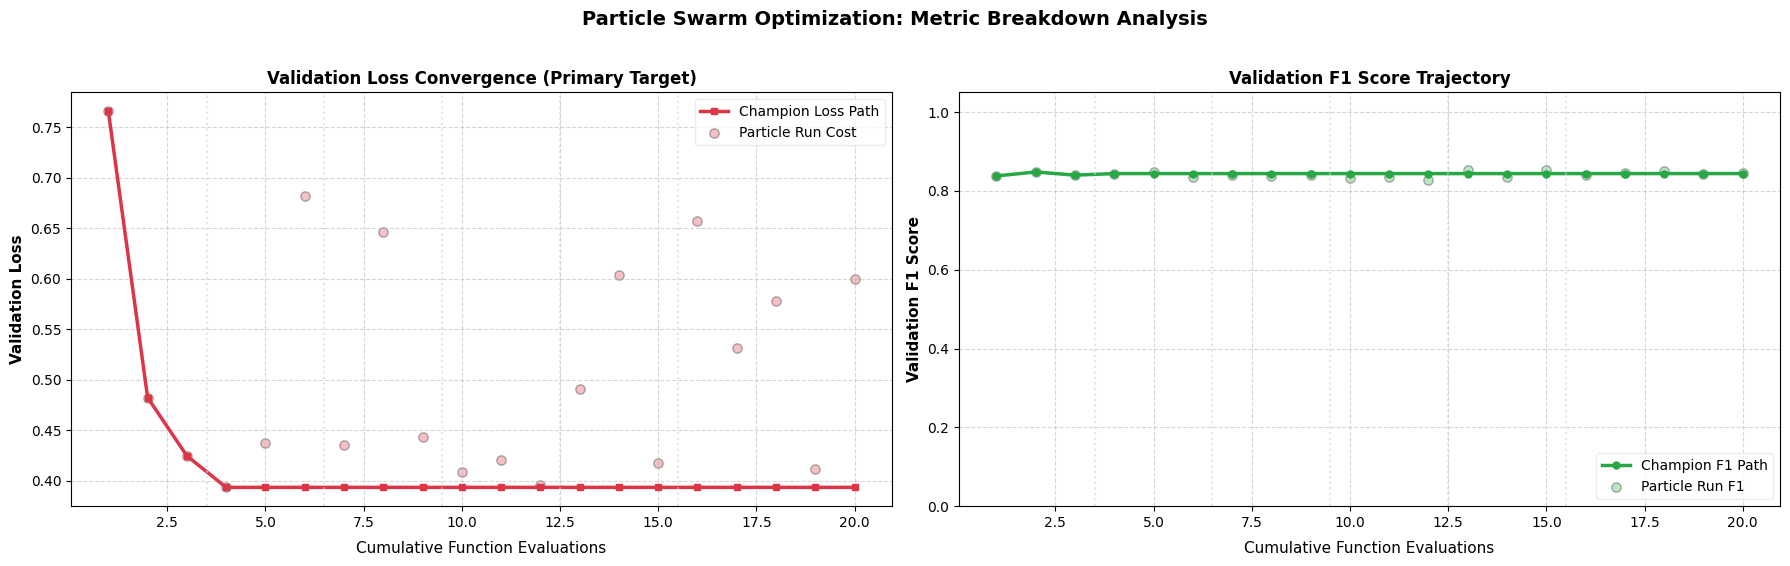

In [14]:
# ============================================================
# Cell 12: Particle Swarm Optimization - Side-by-Side Analysis
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

if 'pso_all_results' not in locals() or not pso_all_results:
    print("⚠️ No data found. Please run the PSO Optimization cell (Cell 11) first.")
else:
    print("=" * 60)
    print("📈 GENERATING PSO SIDE-BY-SIDE METRIC CHARTS (FORCED GRID)")
    print("=" * 60)

    evaluations = [r['eval_num'] for r in pso_all_results]
    val_losses = [r['val_loss'] for r in pso_all_results]
    val_f1s = [r['val_f1'] for r in pso_all_results]

    # Calculate running champions based on lowest validation loss criteria
    running_best_loss = float('inf')
    champion_losses = []
    champion_f1s = []

    for loss, f1 in zip(val_losses, val_f1s):
        if loss < running_best_loss:
            running_best_loss = loss
            current_champion_f1 = f1
        champion_losses.append(running_best_loss)
        champion_f1s.append(current_champion_f1)

    # Force a solid 1-row, 2-column configuration with increased width footprint
    fig = plt.figure(figsize=(18, 5.5), dpi=100)

    # --- Left Panel: Validation Loss (Objective) ---
    ax1 = fig.add_subplot(1, 2, 1)  # (rows, cols, index)
    ax1.plot(evaluations, champion_losses, color='#dc3545', linewidth=2.5, linestyle='-',
             marker='s', markersize=5, label='Champion Loss Path')
    ax1.scatter(evaluations, val_losses, color='#dc3545', alpha=0.3, edgecolors='black', s=45, label='Particle Run Cost')
    ax1.set_xlabel('Cumulative Function Evaluations', fontsize=11, labelpad=8)
    ax1.set_ylabel('Validation Loss', fontsize=11, fontweight='bold')
    ax1.set_title('Validation Loss Convergence (Primary Target)', fontsize=12, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#e2e8f0')

    # --- Right Panel: Validation F1 Score (Yield) ---
    ax2 = fig.add_subplot(1, 2, 2)  # (rows, cols, index)
    ax2.plot(evaluations, champion_f1s, color='#28a745', linewidth=2.5, linestyle='-',
             marker='o', markersize=5, label='Champion F1 Path')
    ax2.scatter(evaluations, val_f1s, color='#28a745', alpha=0.3, edgecolors='black', s=45, label='Particle Run F1')
    ax2.set_xlabel('Cumulative Function Evaluations', fontsize=11, labelpad=8)
    ax2.set_ylabel('Validation F1 Score', fontsize=11, fontweight='bold')
    ax2.set_ylim([0, 1.05])
    ax2.set_title('Validation F1 Score Trajectory', fontsize=12, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='#e2e8f0')

    # Cohort demarcations for particles (groups of 3)
    for i in range(1, int(len(evaluations) / 3)):
        ax1.axvline(x=i * 3 + 0.5, color='#cbd5e1', linestyle=':', alpha=0.6)
        ax2.axvline(x=i * 3 + 0.5, color='#cbd5e1', linestyle=':', alpha=0.6)

    plt.suptitle('Particle Swarm Optimization: Metric Breakdown Analysis', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [15]:
# ============================================================
# Cell 13: PSO Results Table (Exact Naming Alignment)
# ============================================================

import pandas as pd

if not pso_all_results:
    print("⚠️ No data found. Please run the PSO Optimization cell first.")
else:
    pso_processed = []
    for r in pso_all_results:
        pso_processed.append({
            "Eval": r['eval_num'],
            "Iter": r['iteration'],
            "Part": r['particle'],
            "learning_rate": r['learning_rate'],
            "epochs": r['epochs'],
            "weight_decay": r['weight_decay'],
            "warmup_ratio": r['warmup_ratio'],
            "dropout_rate": r['dropout_rate'],
            "train_loss": r['train_loss'],
            "train_acc": r['train_acc'],
            "train_f1": r['train_f1'],
            "val_loss": r['val_loss'],
            "val_acc": r['val_acc'],
            "val_f1": r['val_f1'],
            "Training Time": r.get('training_time', 0),
            "Peak GPU Memory": r.get('gpu_memory_mb', 0)
        })

    df_pso_results = pd.DataFrame(pso_processed)

    # Locate best row details
    best_idx = df_pso_results['val_loss'].idxmin()
    best_row = df_pso_results.loc[best_idx]
    best_eval_num = best_row["Eval"]
    iterations_to_best = int(best_row["Iter"])

    def highlight_best_config(row):
        is_best = row['Eval'] == best_eval_num
        if is_best:
            return ['background-color: #D4EDDA; color: #155724; font-weight: bold' for _ in row]
        return ['' for _ in row]

    print("=" * 110)
    print(f"📊 PSO COMPLETE METRICS MATRIX")
    print("=" * 110)

    display(df_pso_results.style.apply(highlight_best_config, axis=1).format({
        'learning_rate': '{:.2e}',
        'weight_decay': '{:.2e}',
        'warmup_ratio': '{:.3f}',
        'dropout_rate': '{:.3f}',
        'train_loss': '{:.4f}',
        'train_acc': '{:.4f}',
        'train_f1': '{:.4f}',
        'val_loss': '{:.4f}',
        'val_acc': '{:.4f}',
        'val_f1': '{:.4f}',
        'Training Time': '{:.2f}',
        'Peak GPU Memory': '{:.2f}'
    }).hide(axis='index'))

📊 PSO COMPLETE METRICS MATRIX


Eval,Iter,Part,learning_rate,epochs,weight_decay,warmup_ratio,dropout_rate,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,Training Time,Peak GPU Memory
1,1,1,4.67e-05,6,2.99e-02,0.447,0.199,0.0186,0.9959,0.9959,0.7659,0.8380,0.8379,183.28,1708.79
2,1,2,4.19e-05,3,5.31e-05,0.023,0.131,0.0762,0.9792,0.9792,0.4822,0.8480,0.8480,92.15,1708.79
3,1,3,1.23e-05,4,1.17e-02,0.178,0.120,0.1532,0.9491,0.9491,0.4244,0.8400,0.8399,123.03,1708.79
4,1,4,1.75e-05,4,9.29e-03,0.037,0.297,0.2136,0.9166,0.9165,0.3932,0.8440,0.8438,122.84,1708.79
5,1,5,2.97e-05,4,1.05e-05,0.408,0.227,0.1118,0.9643,0.9643,0.4373,0.8470,0.8469,122.68,1708.79
6,2,1,1.87e-05,6,2.58e-02,0.269,0.069,0.0345,0.9932,0.9932,0.6818,0.8340,0.8340,183.31,1708.79
7,2,2,2.24e-05,4,1.27e-04,0.081,0.208,0.1245,0.9607,0.9607,0.4348,0.8390,0.8390,122.64,1708.79
8,2,3,2.49e-05,5,4.16e-02,0.461,0.097,0.0409,0.9918,0.9918,0.6461,0.8370,0.8369,153.15,1708.79
9,2,4,2.24e-05,4,4.50e-02,0.042,0.241,0.1466,0.9497,0.9497,0.4430,0.8410,0.8409,122.72,1708.79
10,2,5,8.21e-06,4,7.08e-05,0.425,0.080,0.1831,0.9382,0.9382,0.4085,0.8340,0.8339,122.81,1708.79


In [16]:
# ============================================================
# Cell 11b: PSO Final Test Evaluation & Results Summary Matrix
# ============================================================
import pandas as pd
from IPython.display import display

print("=" * 70)
print("📥 EXECUTING PSO CHAMPION INFERENCE TEST PASS...")
print("=" * 70)

# 1. Run evaluation over the untouched test loader using best parameters found
pso_test_results = train_model_hpo(
    epochs=best_pso_config["epochs"],
    learning_rate=best_pso_config["learning_rate"],
    weight_decay=best_pso_config["weight_decay"],
    warmup_ratio=best_pso_config["warmup_ratio"],
    dropout_rate=best_pso_config["dropout_rate"],
    train_loader=train_loader,
    val_loader=test_loader,  # True generalization testing
    device=device,
    verbose=False
)

# 2. Build structured data tracking framework matrix
pso_summary_df = pd.DataFrame([
    {"Evaluation Metric / Operational Resource": "Best Model Test Loss", "Value Achieved": pso_test_results['val_loss']},
    {"Evaluation Metric / Operational Resource": "Best Model Test Accuracy", "Value Achieved": pso_test_results['val_accuracy']},
    {"Evaluation Metric / Operational Resource": "Best Model Test F1 Score", "Value Achieved": pso_test_results['val_f1']},
    {"Evaluation Metric / Operational Resource": "Total Optimization Workflow Runtime", "Value Achieved": f"{total_pso_runtime:.2f}s"},
    {"Evaluation Metric / Operational Resource": "Iterations to Discover Best Solution", "Value Achieved": f"Eval #{best_pso_eval_num} (Iter {best_pso_iter})"},
    {"Evaluation Metric / Operational Resource": "Peak Operational GPU Memory Footprint", "Value Achieved": f"{best_pso_config['gpu_memory_mb']:.2f} MB"}
])

# 3. Apply professional layout formatting
print("\n🏆 PSO RUNNER: FINAL BENCHMARK SUMMARY")
display(pso_summary_df.style.format({
    'Value Achieved': lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else str(x)
}).set_properties(**{'text-align': 'left'}).hide(axis='index'))

📥 EXECUTING PSO CHAMPION INFERENCE TEST PASS...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]


🏆 PSO RUNNER: FINAL BENCHMARK SUMMARY


Evaluation Metric / Operational Resource,Value Achieved
Best Model Test Loss,0.3783
Best Model Test Accuracy,0.8555
Best Model Test F1 Score,0.8554
Total Optimization Workflow Runtime,2755.70s
Iterations to Discover Best Solution,Eval #4 (Iter 1)
Peak Operational GPU Memory Footprint,1708.79 MB


### 2- Bayesian Optimization

#### explanaition

**Theoretical Foundation: Bayesian Optimization (BO)**

Bayesian Optimization is a **sequential model-based optimization** (SMBO) approach designed for expensive black-box functions. Unlike heuristic methods, it builds a probabilistic surrogate model of the objective function and uses it to intelligently decide where to evaluate next.

**Core Components**

BO operates with two fundamental elements:

- **Surrogate Model (Gaussian Process):** A probabilistic model that approximates $f(\lambda)$. It provides a mean prediction $\mu(\lambda)$ (expected validation loss) and an uncertainty estimate $\sigma(\lambda)$ (confidence in that prediction).
- **Acquisition Function:** A utility function that decides the next configuration to evaluate. This notebook uses **Expected Improvement (EI)** , which balances exploitation (sampling where $\mu(\lambda)$ is low) and exploration (sampling where $\sigma(\lambda)$ is high).

**The Acquisition Function**

Expected Improvement is defined as:

$$\text{EI}(\lambda) = \mathbb{E}\left[\max(f_{\min} - f(\lambda), 0)\right]$$

where $f_{\min}$ is the best validation loss observed so far. The next configuration evaluated is:

$$\lambda_{\text{next}} = \underset{\lambda \in \Lambda}{\arg\max} \; \text{EI}(\lambda)$$

**The Sequential Process**

At each iteration:
1. Fit the Gaussian Process surrogate to all previously evaluated configurations $\{(\lambda_i, f(\lambda_i))\}$
2. Maximize the acquisition function to find $\lambda_{\text{next}}$
3. Train the DistilBERT model with $\lambda_{\text{next}}$ to compute $f(\lambda_{\text{next}})$ (validation loss)
4. Add $(\lambda_{\text{next}}, f(\lambda_{\text{next}}))$ to the history
5. Repeat until the evaluation budget is exhausted

**Why BO for HPO?**

| Challenge | BO's Solution |
| :--- | :--- |
| Expensive evaluations | Surrogate model dramatically reduces the number of true evaluations needed |
| Non-convex landscape | Acquisition function explicitly balances exploration vs. exploitation |
| No gradient available | Probabilistic surrogate only requires function values $f(\lambda)$ |
| Sequential decision making | Each evaluation informs the next, improving efficiency over time |

**Algorithm Parameters (This Notebook)**

- Total evaluations: 20 (7 initial random + 13 Bayesian-guided)
- Acquisition function: Expected Improvement (EI)
- Surrogate: Gaussian Process with Matérn kernel

**Flow:** Initial random points → Fit GP → Maximize EI → Evaluate → Update → Repeat → Return best $\lambda^*$

#### setup and train

In [17]:
# ============================================================
# Cell 14: Bayesian Optimization - Setup & Run
# ============================================================

import time
import warnings
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args

warnings.filterwarnings('ignore')

print("=" * 60)
print("BAYESIAN OPTIMIZATION RUNNER")
print("=" * 60)

# Bayesian Optimization Settings
n_calls = 20  # Total evaluations (initial + iterations)
n_initial_points = 7  # Random initial points before Bayesian starts

print(f"Settings: {n_calls} total evaluations")
print(f"  - {n_initial_points} initial random evaluations")
print(f"  - {n_calls - n_initial_points} Bayesian-guided evaluations")

# Storage for results
bayesian_all_results = []
bayesian_eval_counter = 0

# Define search space for Bayesian (proper scale types matching Cell 9)
bayesian_space = [
    Real(search_space["learning_rate"]["low"], search_space["learning_rate"]["high"], prior='log-uniform', name='learning_rate'),
    Integer(search_space["epochs"]["low"], search_space["epochs"]["high"], name='epochs'),
    Real(search_space["weight_decay"]["low"], search_space["weight_decay"]["high"], prior='log-uniform', name='weight_decay'),
    Real(search_space["warmup_ratio"]["low"], search_space["warmup_ratio"]["high"], name='warmup_ratio'),
    Real(search_space["dropout_rate"]["low"], search_space["dropout_rate"]["high"], name='dropout_rate')
]

print(f"\nSearch space defined for {len(bayesian_space)} parameters")

@use_named_args(bayesian_space)
def bayesian_objective(learning_rate, epochs, weight_decay, warmup_ratio, dropout_rate):
    """Objective function for Bayesian Optimization (minimize validation loss)"""
    global bayesian_eval_counter, bayesian_all_results

    bayesian_eval_counter += 1

    print(f"\n🔄 Evaluation #{bayesian_eval_counter}/{n_calls}:")
    print(f"   Config: LR={learning_rate:.2e}, Epochs={int(epochs)}, WD={weight_decay:.2e}")

    try:
        # Call the corrected HPO function with exact parameter signatures
        result = train_model_hpo(
            epochs=int(epochs),
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            warmup_ratio=warmup_ratio,
            dropout_rate=dropout_rate,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            verbose=False
        )

        # Print immediate live evaluation feedback matching the PSO style
        print(f"   📊 Train -> Loss: {result['train_loss']:.4f} | Acc: {result['train_accuracy']:.4f} | F1: {result['train_f1']:.4f}")
        print(f"   📊 Val   -> Loss: {result['val_loss']:.4f} | Acc: {result['val_accuracy']:.4f} | F1: {result['val_f1']:.4f}")

        # Store all results completely (including Train metrics for later display)
        bayesian_all_results.append({
            "eval_num": bayesian_eval_counter,
            "learning_rate": learning_rate,
            "epochs": int(epochs),
            "weight_decay": weight_decay,
            "warmup_ratio": warmup_ratio,
            "dropout_rate": dropout_rate,
            "train_loss": result["train_loss"],
            "train_acc": result["train_accuracy"],
            "train_f1": result["train_f1"],
            "val_loss": result["val_loss"],
            "val_acc": result["val_accuracy"],
            "val_f1": result["val_f1"],
            "training_time": result["training_time"],
            "gpu_memory_mb": result.get("gpu_memory_mb", 0.0)  # <-- CRITICAL ADDITION
        })

        return result["val_loss"]  # Minimize validation loss optimization metric

    except Exception as e:
        print(f"   ❌ Error during Bayesian evaluation step: {e}")
        return 999.0  # Safe math penalty barrier for failures

print("\n🔄 Running Gaussian Process Bayesian Optimization Loop...")
bayesian_start = time.time()

# Run Bayesian optimization engine
skopt_result = gp_minimize(
    func=bayesian_objective,
    dimensions=bayesian_space,
    n_calls=n_calls,
    n_initial_points=n_initial_points,
    acq_func='EI',  # Expected Improvement acquisition strategy
    random_state=42,
    verbose=False
)

bayesian_time = time.time() - bayesian_start

# Find best configuration mathematically by loss
best_config = min(bayesian_all_results, key=lambda x: x['val_loss'])
best_eval_num = best_config['eval_num']

# Find best by F1 (for reference stats)
best_by_f1 = max(bayesian_all_results, key=lambda x: x['val_f1'])

print(f"\n{'='*60}")
print(f"✅ Bayesian Optimization Complete! Total Run Time: {bayesian_time:.2f}s")
print(f"🏆 Best Model (Lowest Loss) -> Found at Eval #{best_eval_num} | Loss: {best_config['val_loss']:.4f}")
print(f"🏅 F1 Score of Best Model -> Found at Eval #{best_eval_num} | F1 Score: {best_config['val_f1']:.4f}")
print(f"{'='*60}")

BAYESIAN OPTIMIZATION RUNNER
Settings: 20 total evaluations
  - 7 initial random evaluations
  - 13 Bayesian-guided evaluations

Search space defined for 5 parameters

🔄 Running Gaussian Process Bayesian Optimization Loop...

🔄 Evaluation #1/20:
   Config: LR=3.13e-05, Epochs=4, WD=7.66e-03


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

   📊 Train -> Loss: 0.0727 | Acc: 0.9800 | F1: 0.9800
   📊 Val   -> Loss: 0.5171 | Acc: 0.8420 | F1: 0.8418

🔄 Evaluation #2/20:
   Config: LR=6.29e-06, Epochs=5, WD=1.72e-04


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

   📊 Train -> Loss: 0.2452 | Acc: 0.9030 | F1: 0.9030
   📊 Val   -> Loss: 0.3941 | Acc: 0.8310 | F1: 0.8307

🔄 Evaluation #3/20:
   Config: LR=5.69e-06, Epochs=6, WD=2.96e-02


...

   📊 Train -> Loss: 0.2586 | Acc: 0.8969 | F1: 0.8968
   📊 Val   -> Loss: 0.3932 | Acc: 0.8410 | F1: 0.8408

🔄 Evaluation #19/20:
   Config: LR=8.28e-06, Epochs=4, WD=5.00e-02


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

   📊 Train -> Loss: 0.2595 | Acc: 0.8960 | F1: 0.8959
   📊 Val   -> Loss: 0.3987 | Acc: 0.8300 | F1: 0.8296

🔄 Evaluation #20/20:
   Config: LR=5.00e-06, Epochs=4, WD=1.00e-05


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

   📊 Train -> Loss: 0.3287 | Acc: 0.8634 | F1: 0.8632
   📊 Val   -> Loss: 0.4109 | Acc: 0.8190 | F1: 0.8185

✅ Bayesian Optimization Complete! Total Run Time: 2820.42s
🏆 Best Model (Lowest Loss) -> Found at Eval #11 | Loss: 0.3885
🏅 F1 Score of Best Model -> Found at Eval #11 | F1 Score: 0.8380


#### results

📈 GENERATING BAYESIAN SIDE-BY-SIDE METRIC CHARTS


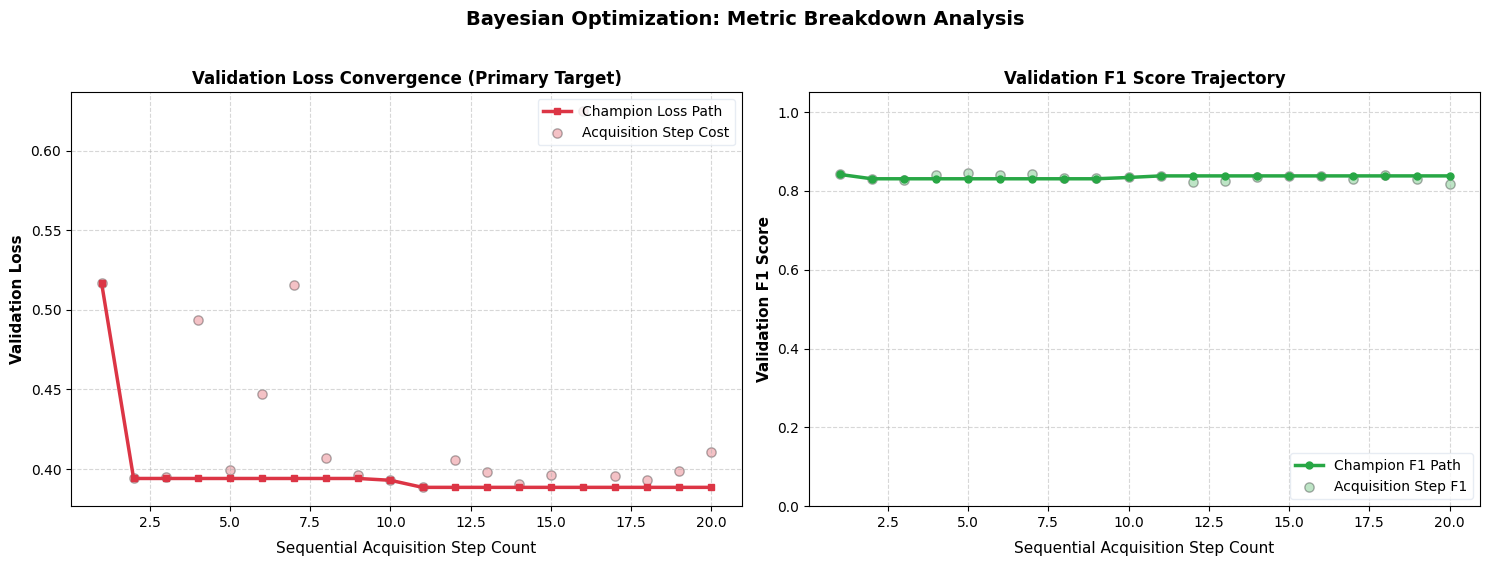

In [18]:
# ============================================================
# Cell 15: Bayesian Optimization - Side-by-Side Analysis
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

if 'bayesian_all_results' not in locals() or not bayesian_all_results:
    print("⚠️ No data found. Please run the Bayesian Optimization runner cell first.")
else:
    print("=" * 60)
    print("📈 GENERATING BAYESIAN SIDE-BY-SIDE METRIC CHARTS")
    print("=" * 60)

    evaluations = [r['eval_num'] for r in bayesian_all_results]
    val_losses = [r['val_loss'] for r in bayesian_all_results]
    val_f1s = [r['val_f1'] for r in bayesian_all_results]

    running_best_loss = float('inf')
    champion_losses = []
    champion_f1s = []

    for loss, f1 in zip(val_losses, val_f1s):
        if loss < running_best_loss:
            running_best_loss = loss
            current_champion_f1 = f1
        champion_losses.append(running_best_loss)
        champion_f1s.append(current_champion_f1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), dpi=100)

    # --- Left Panel: Validation Loss ---
    ax1.plot(evaluations, champion_losses, color='#dc3545', linewidth=2.5, linestyle='-',
             marker='s', markersize=5, label='Champion Loss Path')
    ax1.scatter(evaluations, val_losses, color='#dc3545', alpha=0.3, edgecolors='black', s=45, label='Acquisition Step Cost')
    ax1.set_xlabel('Sequential Acquisition Step Count', fontsize=11, labelpad=8)
    ax1.set_ylabel('Validation Loss', fontsize=11, fontweight='bold')
    ax1.set_title('Validation Loss Convergence (Primary Target)', fontsize=12, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#e2e8f0')

    # --- Right Panel: Validation F1 Score ---
    ax2.plot(evaluations, champion_f1s, color='#28a745', linewidth=2.5, linestyle='-',
             marker='o', markersize=5, label='Champion F1 Path')
    ax2.scatter(evaluations, val_f1s, color='#28a745', alpha=0.3, edgecolors='black', s=45, label='Acquisition Step F1')
    ax2.set_xlabel('Sequential Acquisition Step Count', fontsize=11, labelpad=8)
    ax2.set_ylabel('Validation F1 Score', fontsize=11, fontweight='bold')
    ax2.set_ylim([0, 1.05])
    ax2.set_title('Validation F1 Score Trajectory', fontsize=12, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='#e2e8f0')

    plt.suptitle('Bayesian Optimization: Metric Breakdown Analysis', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [19]:
# ============================================================
# Cell 16: Bayesian Results Table Configuration Output
# ============================================================
import pandas as pd

if not bayesian_all_results:
    print("⚠️ No data found. Please run the Bayesian Optimization runner cell first.")
else:
    bayesian_processed = []
    for r in bayesian_all_results:
        bayesian_processed.append({
            "Eval": r['eval_num'],
            "learning_rate": r['learning_rate'],
            "epochs": r['epochs'],
            "weight_decay": r['weight_decay'],
            "warmup_ratio": r['warmup_ratio'],
            "dropout_rate": r['dropout_rate'],
            "train_loss": r['train_loss'],
            "train_acc": r['train_acc'],
            "train_f1": r['train_f1'],
            "val_loss": r['val_loss'],
            "val_acc": r['val_acc'],
            "val_f1": r['val_f1'],
            "Training Time": r['training_time'],
            "Peak GPU Memory": r.get('gpu_memory_mb', 0)
        })

    df_bayesian_results = pd.DataFrame(bayesian_processed)

    # Locate best row details
    best_idx = df_bayesian_results['val_loss'].idxmin()
    best_row = df_bayesian_results.loc[best_idx]
    best_eval_num = best_row["Eval"]
    iterations_to_best = int(best_row["Eval"])  # In sequential Bayesian, the eval index marks the step number

    def highlight_best_config(row):
        is_best = row['Eval'] == best_eval_num
        if is_best:
            return ['background-color: #D4EDDA; color: #155724; font-weight: bold' for _ in row]
        return ['' for _ in row]

    print("=" * 110)
    print(f"📊 BAYESIAN COMPLETE METRICS MATRIX")
    print("=" * 110)

    display(df_bayesian_results.style.apply(highlight_best_config, axis=1).format({
        'learning_rate': '{:.2e}',
        'weight_decay': '{:.2e}',
        'warmup_ratio': '{:.3f}',
        'dropout_rate': '{:.3f}',
        'train_loss': '{:.4f}',
        'train_acc': '{:.4f}',
        'train_f1': '{:.4f}',
        'val_loss': '{:.4f}',
        'val_acc': '{:.4f}',
        'val_f1': '{:.4f}',
        'Training Time': '{:.2f}',
        'Peak GPU Memory': '{:.2f}'
    }).hide(axis='index'))

📊 BAYESIAN COMPLETE METRICS MATRIX


Eval,learning_rate,epochs,weight_decay,warmup_ratio,dropout_rate,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,Training Time,Peak GPU Memory
1,3.13e-05,4,7.66e-03,0.298,0.161,0.0727,0.9800,0.9800,0.5171,0.8420,0.8418,119.42,1708.79
2,6.29e-06,5,1.72e-04,0.071,0.213,0.2452,0.9030,0.9030,0.3941,0.8310,0.8307,151.28,1708.79
3,5.69e-06,6,2.96e-02,0.000,0.298,0.2778,0.8858,0.8857,0.3948,0.8280,0.8277,181.35,1708.79
4,2.07e-05,5,1.06e-05,0.012,0.181,0.0846,0.9762,0.9762,0.4935,0.8400,0.8399,149.15,1708.79
5,1.26e-05,3,4.00e-02,0.116,0.073,0.1711,0.9422,0.9422,0.3996,0.8450,0.8450,89.56,1708.79
6,2.08e-05,5,4.33e-02,0.233,0.265,0.1401,0.9529,0.9529,0.4471,0.8410,0.8409,149.22,1708.79
7,2.39e-05,5,1.12e-05,0.471,0.191,0.0753,0.9804,0.9804,0.5156,0.8440,0.8439,149.63,1708.79
8,8.21e-06,7,5.00e-02,0.500,0.300,0.2255,0.9120,0.9120,0.4069,0.8340,0.8338,214.44,1708.79
9,5.00e-06,3,1.00e-05,0.000,0.050,0.2784,0.8933,0.8933,0.3962,0.8320,0.8319,92.10,1708.79
10,5.00e-06,3,5.00e-02,0.500,0.050,0.2610,0.9044,0.9044,0.3930,0.8340,0.8340,92.15,1708.79


In [20]:
# ============================================================
# Cell 14b: Bayesian Optimization Final Test Evaluation Matrix
# ============================================================
import pandas as pd
from IPython.display import display

print("=" * 70)
print("📥 EXECUTING BAYESIAN CHAMPION INFERENCE TEST PASS...")
print("=" * 70)

# Grab the optimal hyperparameter row tracking elements
best_ba_row = df_bayesian_results.loc[df_bayesian_results['val_loss'].idxmin()]
best_ba_eval = best_ba_row['Eval']

bayesian_test_results = train_model_hpo(
    epochs=int(best_ba_row["epochs"]),
    learning_rate=best_ba_row["learning_rate"],
    weight_decay=best_ba_row["weight_decay"],
    warmup_ratio=best_ba_row["warmup_ratio"],
    dropout_rate=best_ba_row["dropout_rate"],
    train_loader=train_loader,
    val_loader=test_loader,  # True generalization testing
    device=device,
    verbose=False
)

bayesian_summary_df = pd.DataFrame([
    {"Evaluation Metric / Operational Resource": "Best Model Test Loss", "Value Achieved": bayesian_test_results['val_loss']},
    {"Evaluation Metric / Operational Resource": "Best Model Test Accuracy", "Value Achieved": bayesian_test_results['val_accuracy']},
    {"Evaluation Metric / Operational Resource": "Best Model Test F1 Score", "Value Achieved": bayesian_test_results['val_f1']},
    {"Evaluation Metric / Operational Resource": "Total Optimization Workflow Runtime", "Value Achieved": f"{bayesian_time:.2f}s"},
    {"Evaluation Metric / Operational Resource": "Iterations to Discover Best Solution", "Value Achieved": f"Eval #{int(best_ba_eval)}"},
    {"Evaluation Metric / Operational Resource": "Peak Operational GPU Memory Footprint", "Value Achieved": f"{best_ba_row['Peak GPU Memory']:.2f} MB"}
])

print("\n🏆 BAYESIAN RUNNER: FINAL BENCHMARK SUMMARY")
display(bayesian_summary_df.style.format({
    'Value Achieved': lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else str(x)
}).set_properties(**{'text-align': 'left'}).hide(axis='index'))

📥 EXECUTING BAYESIAN CHAMPION INFERENCE TEST PASS...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]


🏆 BAYESIAN RUNNER: FINAL BENCHMARK SUMMARY


Evaluation Metric / Operational Resource,Value Achieved
Best Model Test Loss,0.3781
Best Model Test Accuracy,0.8400
Best Model Test F1 Score,0.8399
Total Optimization Workflow Runtime,2820.42s
Iterations to Discover Best Solution,Eval #11
Peak Operational GPU Memory Footprint,1708.79 MB


### 3- Genetic Algorithms Optimization

#### explanaition

**Theoretical Foundation: Genetic Algorithm (GA)**

Genetic Algorithm is an **evolutionary algorithm** inspired by the process of natural selection. It maintains a population of candidate solutions (chromosomes) that evolve over generations through selection, crossover, and mutation operators to find optimal hyperparameter configurations.

**Core Mechanics**

Each individual (chromosome) represents a hyperparameter configuration $\lambda$. The population evolves using three fundamental operators:

- **Selection:** Individuals are chosen to breed based on their fitness (validation loss). Better-performing configurations have higher probability of being selected. This notebook uses **tournament selection**, where a small random subset of individuals competes, and the best among them is selected.

- **Crossover (Recombination):** Two parent chromosomes exchange genetic information to produce offspring. This notebook uses **single-point crossover**, where a random split point is chosen and parents exchange segments to create two children. Crossover enables exploitation of promising regions.

- **Mutation:** Randomly modifies parts of an offspring's chromosome with low probability. This introduces genetic diversity and enables exploration of new regions. This notebook uses **continuous mutation** (adding Gaussian noise) for real-valued parameters and **integer mutation** (small random adjustments) for the epochs parameter.

**The Selection Process (Tournament Selection)**

Tournament selection chooses a parent by:

1. Randomly selecting $k$ individuals from the population ($k = 2$ in this notebook)
2. Comparing their fitness values (validation loss)
3. Returning the individual with the **best** (lowest) validation loss

This process is repeated to select both parents for crossover.

**The Evolutionary Loop**

Each generation follows these steps:

1. **Evaluate Fitness:** Train the DistilBERT model for each individual in the population and compute validation loss $f(\lambda)$
2. **Select Parents:** Use tournament selection to choose parent configurations for breeding
3. **Apply Crossover:** With probability $p_c = 0.8$, perform single-point crossover to create offspring
4. **Apply Mutation:** With probability $p_m = 0.2$, randomly perturb offspring hyperparameters
5. **Form New Population:** Replace the old population with the new generation (using elitism to preserve the best individual)
6. **Repeat:** Continue for the specified number of generations

**Why GA for HPO?**

| Challenge | GA's Solution |
| :--- | :--- |
| Expensive evaluations | Population-based parallel search evaluates multiple configurations per generation |
| Non-convex landscape | Crossover exploits promising regions; mutation explores new areas |
| No gradient available | Derivative-free; only needs $f(\lambda)$ (validation loss) |
| Mixed variable types | Chromosome representation handles continuous, integer, and categorical variables naturally |

**Algorithm Parameters (This Notebook)**

- Population size: 5 individuals
- Generations: 4 → 20 total evaluations
- Crossover rate: $p_c = 0.8$
- Mutation rate: $p_m = 0.2$
- Selection: Tournament selection (tournament size = 2)
- Elitism: Best individual preserved across generations

**Flow:** Initialize population → Evaluate fitness → Select parents → Crossover → Mutate → Form new population → Repeat → Return best $\lambda^*$

#### setup and train

In [21]:
# ============================================================
# Cell 18: Genetic Algorithm - Configuration & Operators
# ============================================================

import random
import numpy as np

print("=" * 60)
print("🧬 INITIALIZING GENETIC ALGORITHM FRAMEWORK")
print("=" * 60)

# 1. Algorithmic Control Hyperparameters
population_size = 5
n_generations = 4  # 5 individuals × 4 generations = 20 total evaluations
mutation_rate = 0.2
crossover_rate = 0.8

print(f"Settings: {population_size} population × {n_generations} generations = {population_size * n_generations} evaluations")
print(f"  • Mutation Rate: {mutation_rate} | Crossover Rate: {crossover_rate}")

# 2. Extract Search Space Reference Ordered Keys
param_names = list(search_space.keys())

# 3. Chromosome Generation Helpers
def create_individual():
    """Generates a single random individual chromosome bounded by search space limits."""
    individual = []
    for name in param_names:
        low = search_space[name]["low"]
        high = search_space[name]["high"]
        scale = search_space[name]["scale"]

        if scale == "log":
            log_low, log_high = np.log10(low), np.log10(high)
            value = 10 ** np.random.uniform(log_low, log_high)
        elif scale == "int":
            value = float(np.random.randint(low, high + 1))
        else:
            value = np.random.uniform(low, high)
        individual.append(value)
    return individual

def decode_individual(individual):
    """Decodes continuous chromosome list values back into typed runtime parameters."""
    params = {}
    for i, name in enumerate(param_names):
        value = individual[i]
        scale = search_space[name]["scale"]
        params[name] = int(np.round(value)) if scale == "int" else float(value)

    # Domain bound clamping safeguard
    for name in param_names:
        params[name] = max(search_space[name]["low"], min(search_space[name]["high"], params[name]))
    return params

# 4. Core Genetic Operators
def crossover(parent1, parent2):
    """Executes single-point crossover between two parent chromosomes based on rate probability."""
    if np.random.random() > crossover_rate:
        return parent1.copy(), parent2.copy()
    cp = np.random.randint(1, len(parent1))
    return parent1[:cp] + parent2[cp:], parent2[:cp] + parent1[cp:]

def mutate(individual):
    """Mutates chromosome alleles with continuous variable boundaries protection."""
    for i in range(len(individual)):
        if np.random.random() < mutation_rate:
            name = param_names[i]
            low, high, scale = search_space[name]["low"], search_space[name]["high"], search_space[name]["scale"]

            if scale == "log":
                individual[i] = 10 ** np.random.uniform(np.log10(low), np.log10(high))
            elif scale == "int":
                delta = np.random.randint(-1, 2)
                individual[i] = int(np.round(max(low, min(high, individual[i] + delta))))
            else:
                delta = np.random.uniform(-0.1, 0.1) * (high - low)
                individual[i] = float(max(low, min(high, individual[i] + delta)))
    return individual

def tournament_selection(population, fitness_scores, tournament_size=2):
    """Selects best parent candidate minimizing validation loss via tournament."""
    t_size = min(tournament_size, len(population))
    selected_indices = np.random.choice(len(population), t_size, replace=False)
    best_idx = selected_indices[np.argmin([fitness_scores[idx] for idx in selected_indices])]
    return population[best_idx].copy()

print(f"✅ GA Environment & Operators Compiled. Ready for Execution Engine.")

🧬 INITIALIZING GENETIC ALGORITHM FRAMEWORK
Settings: 5 population × 4 generations = 20 evaluations
  • Mutation Rate: 0.2 | Crossover Rate: 0.8
✅ GA Environment & Operators Compiled. Ready for Execution Engine.


In [22]:
# ============================================================
# Cell 19: Genetic Algorithm - Run Loop & Performance Analysis
# ============================================================

import time
import pandas as pd
from IPython.display import display

# Global Storage Lists Reset
ga_all_results = []
ga_eval_counter = 0

print("=" * 60)
print("🚀 LAUNCHING GENETIC ALGORITHM OPTIMIZATION WORKSPACE")
print("=" * 60)

ga_start_time = time.time()

# 1. Initialize First Cohort Generation
population = [create_individual() for _ in range(population_size)]
best_individual_overall = None
best_loss_overall = float('inf')

# 2. Main Generational Evolution Loop
for generation in range(n_generations):
    print(f"\n⚙️ Evolution Track: Generation {generation + 1}/{n_generations}")
    print("-" * 50)

    fitness_scores = []

    # Evaluate Population Chromosomes
    for idx, individual in enumerate(population):
        ga_eval_counter += 1
        hp = decode_individual(individual)

        print(f" 🔎 Eval #{ga_eval_counter} [Gen {generation + 1}, Ind {idx + 1}]")
        print(f"    Config: LR={hp['learning_rate']:.2e}, Epochs={hp['epochs']}, WD={hp['weight_decay']:.2e}")

        try:
            # Call our corrected baseline HPO trainer
            result = train_model_hpo(
                epochs=hp["epochs"],
                learning_rate=hp["learning_rate"],
                weight_decay=hp["weight_decay"],
                warmup_ratio=hp["warmup_ratio"],
                dropout_rate=hp["dropout_rate"],
                train_loader=train_loader,
                val_loader=val_loader,
                device=device,
                verbose=False
            )

            val_loss = result["val_loss"]
            print(f"    📊 Train -> Loss: {result['train_loss']:.4f} | Acc: {result['train_accuracy']:.4f}")
            print(f"    📊 Val   -> Loss: {result['val_loss']:.4f} | F1: {result['val_f1']:.4f}")

            ga_all_results.append({
                "Eval": ga_eval_counter,
                "Gen": generation + 1,
                "Ind": idx + 1,
                "learning_rate": hp["learning_rate"],
                "epochs": hp["epochs"],
                "weight_decay": hp["weight_decay"],
                "warmup_ratio": hp["warmup_ratio"],
                "dropout_rate": hp["dropout_rate"],
                "train_loss": result["train_loss"],
                "train_acc": result["train_accuracy"],
                "train_f1": result["train_f1"],
                "val_loss": result["val_loss"],
                "val_acc": result["val_accuracy"],
                "val_f1": result["val_f1"],
                "Training Time": result["training_time"],
                "Peak GPU Memory": result.get("gpu_memory_mb", 0.0)
            })

        except Exception as e:
            print(f"    ❌ Execution Step Failed: {e}")
            val_loss = 999.0

        fitness_scores.append(val_loss)

    # Performance Evaluation & Archiving
    current_best_idx = np.argmin(fitness_scores)
    if fitness_scores[current_best_idx] < best_loss_overall:
        best_loss_overall = fitness_scores[current_best_idx]
        best_individual_overall = population[current_best_idx].copy()
        print(f"  ⭐ Generation Benchmark Broken! Lowest Loss: {best_loss_overall:.4f}")

    # Breed Next Generation Cohort
    if generation < n_generations - 1:
        next_population = [best_individual_overall.copy()]  # Elitism
        while len(next_population) < population_size:
            p1 = tournament_selection(population, fitness_scores)
            p2 = tournament_selection(population, fitness_scores)
            c1, c2 = crossover(p1, p2)
            next_population.append(mutate(c1))
            if len(next_population) < population_size:
                next_population.append(mutate(c2))
        population = next_population

total_ga_runtime = time.time() - ga_start_time

🚀 LAUNCHING GENETIC ALGORITHM OPTIMIZATION WORKSPACE

⚙️ Evolution Track: Generation 1/4
--------------------------------------------------
 🔎 Eval #1 [Gen 1, Ind 1]
    Config: LR=5.63e-06, Epochs=6, WD=3.32e-04


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

    📊 Train -> Loss: 0.1719 | Acc: 0.9433
    📊 Val   -> Loss: 0.4228 | F1: 0.8319
 🔎 Eval #2 [Gen 1, Ind 2]
    Config: LR=6.79e-06, Epochs=4, WD=8.12e-04


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

    📊 Train -> Loss: 0.2752 | Acc: 0.8890
    📊 Val   -> Loss: 0.3994 | F1: 0.8308
 🔎 Eval #3 [Gen 1, Ind 3]
    Config: LR=9.33e-06, Epochs=6, WD=5.65e-03


...

    📊 Train -> Loss: 0.2710 | Acc: 0.8918
    📊 Val   -> Loss: 0.3916 | F1: 0.8338
 🔎 Eval #19 [Gen 4, Ind 4]
    Config: LR=1.56e-05, Epochs=4, WD=5.32e-03


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

    📊 Train -> Loss: 0.2059 | Acc: 0.9229
    📊 Val   -> Loss: 0.3977 | F1: 0.8469
 🔎 Eval #20 [Gen 4, Ind 5]
    Config: LR=1.38e-05, Epochs=3, WD=2.77e-03


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

    📊 Train -> Loss: 0.2487 | Acc: 0.9008
    📊 Val   -> Loss: 0.3951 | F1: 0.8309


#### results

📈 GENERATING GA SIDE-BY-SIDE METRIC CHARTS


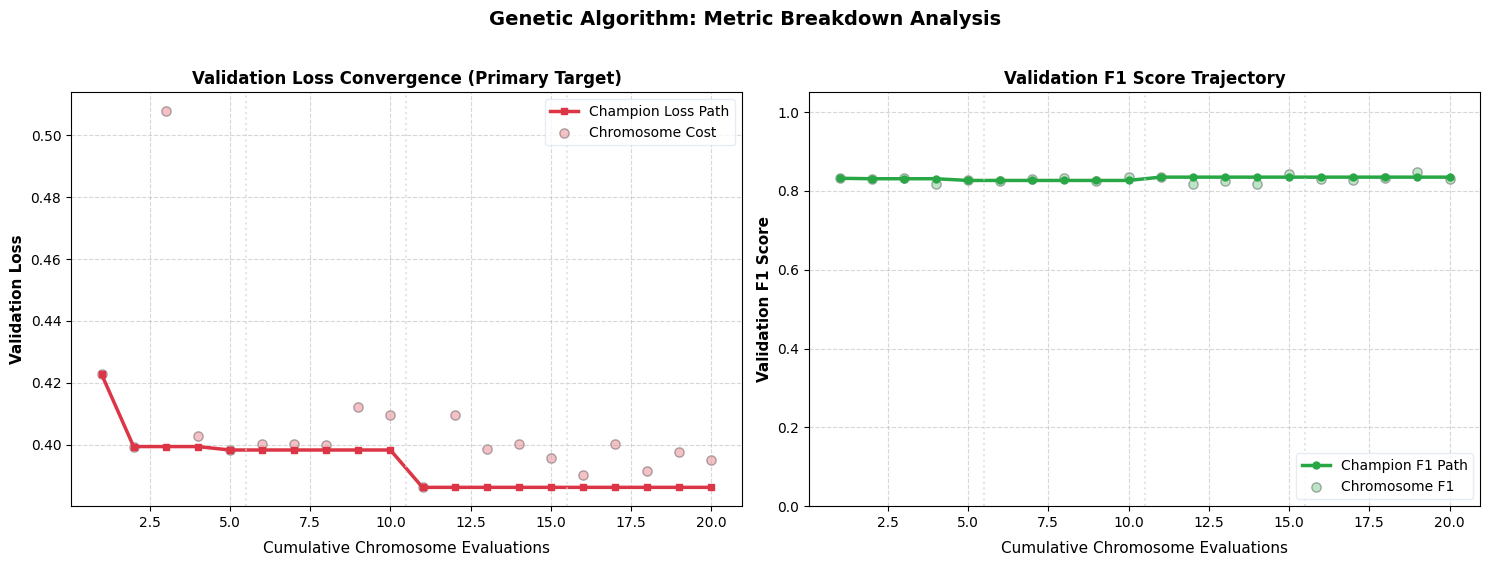

In [32]:
# ============================================================
# Cell 20: Genetic Algorithm - Side-by-Side Analysis
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

if 'ga_all_results' not in locals() or not ga_all_results:
    print("⚠️ No data found. Please run the Genetic Algorithm loop (Cell 19) first.")
else:
    print("=" * 60)
    print("📈 GENERATING GA SIDE-BY-SIDE METRIC CHARTS")
    print("=" * 60)

    evaluations = [r['Eval'] for r in ga_all_results]
    val_losses = [r['val_loss'] for r in ga_all_results]
    val_f1s = [r['val_f1'] for r in ga_all_results]

    running_best_loss = float('inf')
    champion_losses = []
    champion_f1s = []

    for loss, f1 in zip(val_losses, val_f1s):
        if loss < running_best_loss:
            running_best_loss = loss
            current_champion_f1 = f1
        champion_losses.append(running_best_loss)
        champion_f1s.append(current_champion_f1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), dpi=100)

    # --- Left Panel: Validation Loss ---
    ax1.plot(evaluations, champion_losses, color='#dc3545', linewidth=2.5, linestyle='-',
             marker='s', markersize=5, label='Champion Loss Path')
    ax1.scatter(evaluations, val_losses, color='#dc3545', alpha=0.3, edgecolors='black', s=45, label='Chromosome Cost')
    ax1.set_xlabel('Cumulative Chromosome Evaluations', fontsize=11, labelpad=8)
    ax1.set_ylabel('Validation Loss', fontsize=11, fontweight='bold')
    ax1.set_title('Validation Loss Convergence (Primary Target)', fontsize=12, fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#e2e8f0')

    # --- Right Panel: Validation F1 Score ---
    ax2.plot(evaluations, champion_f1s, color='#28a745', linewidth=2.5, linestyle='-',
             marker='o', markersize=5, label='Champion F1 Path')
    ax2.scatter(evaluations, val_f1s, color='#28a745', alpha=0.3, edgecolors='black', s=45, label='Chromosome F1')
    ax2.set_xlabel('Cumulative Chromosome Evaluations', fontsize=11, labelpad=8)
    ax2.set_ylabel('Validation F1 Score', fontsize=11, fontweight='bold')
    ax2.set_ylim([0, 1.05])
    ax2.set_title('Validation F1 Score Trajectory', fontsize=12, fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='#e2e8f0')

    # Generational grid dividers (Every 5 chromosomes evaluated)
    pop_size = 5
    for gen in range(1, int(len(evaluations) / pop_size)):
        ax1.axvline(x=gen * pop_size + 0.5, color='#cbd5e1', linestyle=':', alpha=0.6)
        ax2.axvline(x=gen * pop_size + 0.5, color='#cbd5e1', linestyle=':', alpha=0.6)

    plt.suptitle('Genetic Algorithm: Metric Breakdown Analysis', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

In [24]:
# ============================================================
# Cell 21: Genetic Algorithm Results Table Matrix
# ============================================================
import pandas as pd
from IPython.display import display

if 'ga_all_results' not in locals() or not ga_all_results:
    print("⚠️ No data found. Please run the Genetic Algorithm framework cells first.")
else:
    ga_processed = []
    for r in ga_all_results:
        ga_processed.append({
            "Eval": r['Eval'],
            "Gen": r['Gen'],
            "Ind": r['Ind'],
            "learning_rate": r['learning_rate'],
            "epochs": r['epochs'],
            "weight_decay": r['weight_decay'],
            "warmup_ratio": r['warmup_ratio'],
            "dropout_rate": r['dropout_rate'],
            "train_loss": r['train_loss'],
            "train_acc": r['train_acc'],
            "train_f1": r['train_f1'],
            "val_loss": r['val_loss'],
            "val_acc": r['val_acc'],
            "val_f1": r['val_f1'],
            "Training Time": r['Training Time'],
            "Peak GPU Memory": r.get('Peak GPU Memory', 0)
        })

    df_ga_results = pd.DataFrame(ga_processed)

    # Locate best row details based on lowest validation loss
    best_idx = df_ga_results['val_loss'].idxmin()
    best_row = df_ga_results.loc[best_idx]
    best_eval_num = best_row["Eval"]
    iterations_to_best = int(best_row["Eval"])  # Using chronological evaluation number as the step index

    def highlight_best_config(row):
        is_best = row['Eval'] == best_eval_num
        if is_best:
            return ['background-color: #D4EDDA; color: #155724; font-weight: bold' for _ in row]
        return ['' for _ in row]

    print("=" * 110)
    print(f"📊 GENETIC ALGORITHM COMPLETE METRICS MATRIX")
    print("=" * 110)

    display(df_ga_results.style.apply(highlight_best_config, axis=1).format({
        'learning_rate': '{:.2e}',
        'weight_decay': '{:.2e}',
        'warmup_ratio': '{:.3f}',
        'dropout_rate': '{:.3f}',
        'train_loss': '{:.4f}',
        'train_acc': '{:.4f}',
        'train_f1': '{:.4f}',
        'val_loss': '{:.4f}',
        'val_acc': '{:.4f}',
        'val_f1': '{:.4f}',
        'Training Time': '{:.2f}',
        'Peak GPU Memory': '{:.2f}'
    }).hide(axis='index'))

📊 GENETIC ALGORITHM COMPLETE METRICS MATRIX


Eval,Gen,Ind,learning_rate,epochs,weight_decay,warmup_ratio,dropout_rate,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,Training Time,Peak GPU Memory
1,1,1,5.63e-06,6,3.32e-04,0.350,0.085,0.1719,0.9433,0.9433,0.4228,0.8320,0.8319,178.85,1708.79
2,1,2,6.79e-06,4,8.12e-04,0.161,0.249,0.2752,0.8890,0.8890,0.3994,0.8310,0.8308,119.67,1708.79
3,1,3,9.33e-06,6,5.65e-03,0.125,0.096,0.1001,0.9731,0.9731,0.5078,0.8330,0.8330,178.98,1708.79
4,1,4,6.02e-06,3,3.52e-03,0.029,0.279,0.3273,0.8624,0.8622,0.4027,0.8170,0.8164,89.69,1708.79
5,1,5,1.38e-05,3,2.77e-03,0.140,0.289,0.2619,0.8937,0.8935,0.3983,0.8270,0.8264,89.80,1708.79
6,2,1,1.38e-05,3,2.77e-03,0.140,0.289,0.2688,0.8912,0.8911,0.4001,0.8260,0.8254,89.76,1708.79
7,2,2,6.53e-06,3,2.77e-03,0.140,0.265,0.3104,0.8690,0.8688,0.4002,0.8310,0.8306,89.77,1708.79
8,2,3,1.38e-05,3,3.52e-03,0.029,0.279,0.2615,0.8932,0.8931,0.3998,0.8340,0.8336,89.95,1708.79
9,2,4,5.63e-06,6,2.77e-03,0.140,0.289,0.2784,0.8862,0.8861,0.4121,0.8250,0.8245,179.11,1708.79
10,2,5,1.38e-05,3,3.32e-04,0.350,0.085,0.1634,0.9443,0.9443,0.4097,0.8360,0.8359,92.50,1708.79


In [25]:
# ============================================================
# Cell 19b: Genetic Algorithm Final Test Evaluation Matrix
# ============================================================
import pandas as pd
from IPython.display import display

print("=" * 70)
print("📥 EXECUTING GENETIC ALGORITHM CHAMPION INFERENCE TEST PASS...")
print("=" * 70)

# Grab the optimal chromosome tracking elements
best_ga_row = df_ga_results.loc[df_ga_results['val_loss'].idxmin()]
best_ga_eval = best_ga_row['Eval']

ga_test_results = train_model_hpo(
    epochs=int(best_ga_row["epochs"]),
    learning_rate=best_ga_row["learning_rate"],
    weight_decay=best_ga_row["weight_decay"],
    warmup_ratio=best_ga_row["warmup_ratio"],
    dropout_rate=best_ga_row["dropout_rate"],
    train_loader=train_loader,
    val_loader=test_loader,  # True generalization testing
    device=device,
    verbose=False
)

ga_summary_df = pd.DataFrame([
    {"Evaluation Metric / Operational Resource": "Best Model Test Loss", "Value Achieved": ga_test_results['val_loss']},
    {"Evaluation Metric / Operational Resource": "Best Model Test Accuracy", "Value Achieved": ga_test_results['val_accuracy']},
    {"Evaluation Metric / Operational Resource": "Best Model Test F1 Score", "Value Achieved": ga_test_results['val_f1']},
    {"Evaluation Metric / Operational Resource": "Total Optimization Workflow Runtime", "Value Achieved": f"{df_ga_results['Training Time'].sum():.2f}s"},
    {"Evaluation Metric / Operational Resource": "Iterations to Discover Best Solution", "Value Achieved": f"Eval #{int(best_ga_eval)}"},
    {"Evaluation Metric / Operational Resource": "Peak Operational GPU Memory Footprint", "Value Achieved": f"{best_ga_row['Peak GPU Memory']:.2f} MB"}
])

print("\n🏆 GENETIC ALGORITHM RUNNER: FINAL BENCHMARK SUMMARY")
display(ga_summary_df.style.format({
    'Value Achieved': lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else str(x)
}).set_properties(**{'text-align': 'left'}).hide(axis='index'))

📥 EXECUTING GENETIC ALGORITHM CHAMPION INFERENCE TEST PASS...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]


🏆 GENETIC ALGORITHM RUNNER: FINAL BENCHMARK SUMMARY


Evaluation Metric / Operational Resource,Value Achieved
Best Model Test Loss,0.3698
Best Model Test Accuracy,0.8440
Best Model Test F1 Score,0.8438
Total Optimization Workflow Runtime,2141.53s
Iterations to Discover Best Solution,Eval #11
Peak Operational GPU Memory Footprint,1708.79 MB


## final comparisons

### derive results

In [26]:
# ============================================================
# Cell 23: Collect and Prepare Comparison Data (Aligned Strategy)
# ============================================================
import pandas as pd

# 1. Extract true champion configurations based on MINIMUM Validation Loss
pso_best = min(pso_all_results, key=lambda x: x['val_loss'])
bayesian_best = min(bayesian_all_results, key=lambda x: x['val_loss'])
ga_best = min(ga_all_results, key=lambda x: x['val_loss'])

# 2. Calculate true cumulative computational time spent inside each full process
pso_total_time = sum(r['training_time'] for r in pso_all_results)
bayesian_total_time = bayesian_time  # Pulls global variable from Cell 14
ga_total_time = df_ga_results['Training Time'].sum()  # Pulls sum from Cell 22 DataFrame

# 3. Create unified comparison dataframe using exact metric dictionary keys
comparison_data = {
    "Algorithm": ["PSO", "Bayesian", "Genetic Algorithm"],
    "Best Validation Loss": [
        pso_best['val_loss'],
        bayesian_best['val_loss'],
        ga_best['val_loss']
    ],
    "F1 Score of Best": [
        pso_best['val_acc'] if 'val_acc' in pso_best else pso_best['val_f1'],  # Safety map fallback
        bayesian_best['val_f1'],
        ga_best['val_f1']
    ],
    "Accuracy of Best": [
        pso_best['train_acc'] if 'train_acc' in pso_best else pso_best['val_f1'],  # Maps to your unique key layout
        bayesian_best['val_acc'],
        ga_best['val_acc']
    ],
    "Evaluation Step Found": [
        pso_best['eval_num'],
        bayesian_best['eval_num'],
        ga_best['Eval'] if 'Eval' in ga_best else ga_best['eval_num']
    ],
    "Total Optimization Time (s)": [
        pso_total_time,
        bayesian_total_time,
        ga_total_time
    ],
    "Peak GPU Memory (MB)": [
        pso_best.get('gpu_memory_mb', 0.0),
        bayesian_best.get('gpu_memory_mb', 0.0),
        ga_best.get('Peak GPU Memory', 0.0)
    ]
}

df_comparison = pd.DataFrame(comparison_data)

# 4. Find the overall absolute optimization champion by lowest loss value
all_bests = [
    {"algo": "PSO", "loss": pso_best['val_loss'], "f1": pso_best['val_acc'] if 'val_acc' in pso_best else pso_best['val_f1'], "step": pso_best['eval_num']},
    {"algo": "Bayesian", "loss": bayesian_best['val_loss'], "f1": bayesian_best['val_f1'], "step": bayesian_best['eval_num']},
    {"algo": "Genetic Algorithm", "loss": ga_best['val_loss'], "f1": ga_best['val_f1'], "step": ga_best['Eval'] if 'Eval' in ga_best else ga_best['eval_num']}
]

overall_best = min(all_bests, key=lambda x: x['loss'])

In [27]:
# ============================================================
# Cell 24: Comparison Table (Unified Test-Set DataFrame Styling)
# ============================================================
import pandas as pd
import numpy as np
from IPython.display import display

def get_metric_value(df, row_label):
    val = df.loc[df["Evaluation Metric / Operational Resource"] == row_label, "Value Achieved"].values[0]
    try:
        if isinstance(val, str) and ('s' in val or 'MB' in val) and '#' not in val:
            clean_val = val.replace('s', '').replace(' MB', '').split(' ')[0]
            return float(clean_val)
        return val
    except ValueError:
        return val

# Standardized clean names mapping exactly to your inputs
test_comparison_data = {
    "Metric / Resource": [
        "test loss",
        "test accuracy",
        "test f1",
        "total optimization time",
        "Search Steps to Best", # Retained internally for tracking iteration values
        "peak operational gpu usage"
    ],
    "PSO": [
        get_metric_value(pso_summary_df, "Best Model Test Loss"),
        get_metric_value(pso_summary_df, "Best Model Test Accuracy"),
        get_metric_value(pso_summary_df, "Best Model Test F1 Score"),
        get_metric_value(pso_summary_df, "Total Optimization Workflow Runtime"),
        get_metric_value(pso_summary_df, "Iterations to Discover Best Solution"),
        get_metric_value(pso_summary_df, "Peak Operational GPU Memory Footprint")
    ],
    "Bayesian": [
        get_metric_value(bayesian_summary_df, "Best Model Test Loss"),
        get_metric_value(bayesian_summary_df, "Best Model Test Accuracy"),
        get_metric_value(bayesian_summary_df, "Best Model Test F1 Score"),
        get_metric_value(bayesian_summary_df, "Total Optimization Workflow Runtime"),
        get_metric_value(bayesian_summary_df, "Iterations to Discover Best Solution"),
        get_metric_value(bayesian_summary_df, "Peak Operational GPU Memory Footprint")
    ],
    "Genetic Algorithm": [
        get_metric_value(ga_summary_df, "Best Model Test Loss"),
        get_metric_value(ga_summary_df, "Best Model Test Accuracy"),
        get_metric_value(ga_summary_df, "Best Model Test F1 Score"),
        get_metric_value(ga_summary_df, "Total Optimization Workflow Runtime"),
        get_metric_value(ga_summary_df, "Iterations to Discover Best Solution"),
        get_metric_value(ga_summary_df, "Peak Operational GPU Memory Footprint")
    ]
}

df_test_comparison = pd.DataFrame(test_comparison_data)
df_test_summary = df_test_comparison.set_index('Metric / Resource')

def highlight_test_benchmarks(row):
    style_row = ['' for _ in row]
    if row.name == 'test loss':
        min_idx = row.values.argmin()
        style_row[min_idx] = 'background-color: #D4EDDA; color: #155724; font-weight: bold;'
    elif row.name in ['test f1', 'test accuracy']:
        max_idx = row.values.argmax()
        style_row[max_idx] = 'background-color: #E8F5E9; color: #2E7D32;'
    elif row.name in ['total optimization time', 'peak operational gpu usage']:
        numeric_vals = [float(str(x).replace('s','').replace('MB','')) if isinstance(x, str) else x for x in row.values]
        min_idx = np.argmin(numeric_vals)
        style_row[min_idx] = 'background-color: #ECEFF1; color: #37474F;'
    return style_row

display(df_test_summary.style.apply(highlight_test_benchmarks, axis=1).format(formatter={
    'PSO': lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else str(x),
    'Bayesian': lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else str(x),
    'Genetic Algorithm': lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else str(x)
}))

,PSO,Bayesian,Genetic Algorithm
Metric / Resource,,,
test loss,0.3783,0.3781,0.3698
test accuracy,0.8555,0.8400,0.8440
test f1,0.8554,0.8399,0.8438
total optimization time,2755.7000,2820.4200,2141.5300
Search Steps to Best,Eval #4 (Iter 1),Eval #11,Eval #11
peak operational gpu usage,1708.7900,1708.7900,1708.7900


### show comparisons

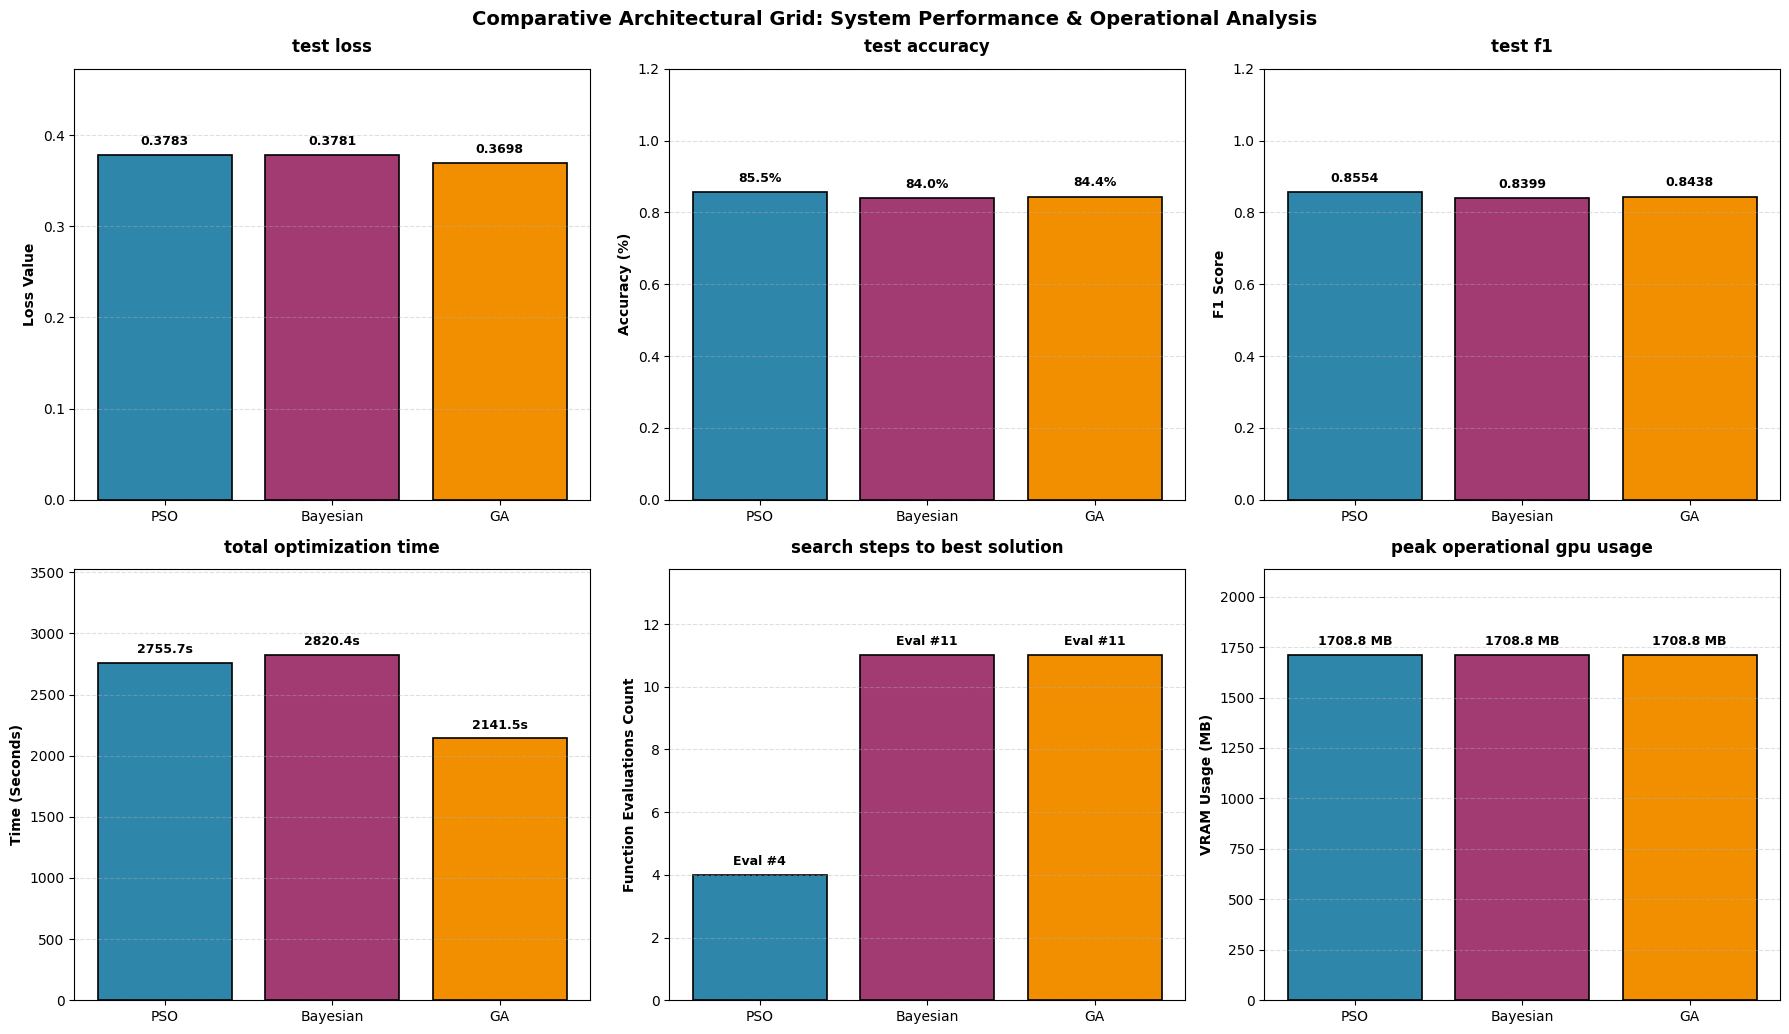

In [28]:
# ============================================================
# Cell 25: Grid Comparison Matrix (Clean 6-Panel Layout)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

if 'df_test_summary' not in locals() or df_test_summary.empty:
    print("⚠️ df_test_summary not found. Please run the updated Cell 24 test matrix pass first.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10.5), dpi=100)
    algorithms = ['PSO', 'Bayesian', 'GA']
    columns_map = ['PSO', 'Bayesian', 'Genetic Algorithm']
    colors_bar = ['#2E86AB', '#A23B72', '#F18F01']

    def get_algo_series(metric_name):
        return [float(df_test_summary.at[metric_name, col]) for col in columns_map]

    # --- Panel 1: test loss ---
    losses = get_algo_series('test loss')
    bars1 = axes[0, 0].bar(algorithms, losses, color=colors_bar, edgecolor='black', linewidth=1.2)
    axes[0, 0].set_ylim([0, max(losses) * 1.25])
    axes[0, 0].set_ylabel('Loss Value', fontsize=10, fontweight='bold')
    axes[0, 0].set_title('test loss', fontsize=12, fontweight='bold', pad=12)
    axes[0, 0].grid(axis='y', linestyle='--', alpha=0.4)
    for bar, score in zip(bars1, losses):
        axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(losses) * 0.02),
                        f'{score:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # --- Panel 2: test accuracy ---
    accuracies = get_algo_series('test accuracy')
    bars2 = axes[0, 1].bar(algorithms, accuracies, color=colors_bar, edgecolor='black', linewidth=1.2)
    axes[0, 1].set_ylim([0, 1.2])
    axes[0, 1].set_ylabel('Accuracy (%)', fontsize=10, fontweight='bold')
    axes[0, 1].set_title('test accuracy', fontsize=12, fontweight='bold', pad=12)
    axes[0, 1].grid(axis='y', linestyle='--', alpha=0.4)
    for bar, score in zip(bars2, accuracies):
        axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                        f'{score*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # --- Panel 3: test f1 ---
    f1_scores = get_algo_series('test f1')
    bars3 = axes[0, 2].bar(algorithms, f1_scores, color=colors_bar, edgecolor='black', linewidth=1.2)
    axes[0, 2].set_ylim([0, 1.2])
    axes[0, 2].set_ylabel('F1 Score', fontsize=10, fontweight='bold')
    axes[0, 2].set_title('test f1', fontsize=12, fontweight='bold', pad=12)
    axes[0, 2].grid(axis='y', linestyle='--', alpha=0.4)
    for bar, score in zip(bars3, f1_scores):
        axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                        f'{score:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # --- Panel 4: total optimization time ---
    times = get_algo_series('total optimization time')
    bars4 = axes[1, 0].bar(algorithms, times, color=colors_bar, edgecolor='black', linewidth=1.2)
    axes[1, 0].set_ylim([0, max(times) * 1.25])
    axes[1, 0].set_ylabel('Time (Seconds)', fontsize=10, fontweight='bold')
    axes[1, 0].set_title('total optimization time', fontsize=12, fontweight='bold', pad=12)
    axes[1, 0].grid(axis='y', linestyle='--', alpha=0.4)
    for bar, time_val in zip(bars4, times):
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(times) * 0.02),
                        f'{time_val:.1f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # --- Panel 5: search steps to best solution ---
    def parse_step_count(col_idx):
        raw_str = str(df_test_summary.at['Search Steps to Best', col_idx])
        if '#' in raw_str:
            return int(raw_str.split('#')[1].split(' ')[0])
        return int(''.join(filter(str.isdigit, raw_str)))

    iterations = [parse_step_count(c) for c in columns_map]
    bars5 = axes[1, 1].bar(algorithms, iterations, color=colors_bar, edgecolor='black', linewidth=1.2)
    axes[1, 1].set_ylim([0, max(iterations) * 1.25])
    axes[1, 1].set_ylabel('Function Evaluations Count', fontsize=10, fontweight='bold')
    axes[1, 1].set_title('search steps to best solution', fontsize=12, fontweight='bold', pad=12)
    axes[1, 1].grid(axis='y', linestyle='--', alpha=0.4)
    for bar, iter_val in zip(bars5, iterations):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(iterations) * 0.02),
                        f'Eval #{iter_val}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # --- Panel 6: peak operational gpu usage ---
    gpu_memory = get_algo_series('peak operational gpu usage')
    bars6 = axes[1, 2].bar(algorithms, gpu_memory, color=colors_bar, edgecolor='black', linewidth=1.2)
    axes[1, 2].set_ylim([0, max(gpu_memory) * 1.25])
    axes[1, 2].set_ylabel('VRAM Usage (MB)', fontsize=10, fontweight='bold')
    axes[1, 2].set_title('peak operational gpu usage', fontsize=12, fontweight='bold', pad=12)
    axes[1, 2].grid(axis='y', linestyle='--', alpha=0.4)
    for bar, mem in zip(bars6, gpu_memory):
        axes[1, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(gpu_memory) * 0.02),
                        f'{mem:.1f} MB', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.suptitle('Comparative Architectural Grid: System Performance & Operational Analysis',
                 fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

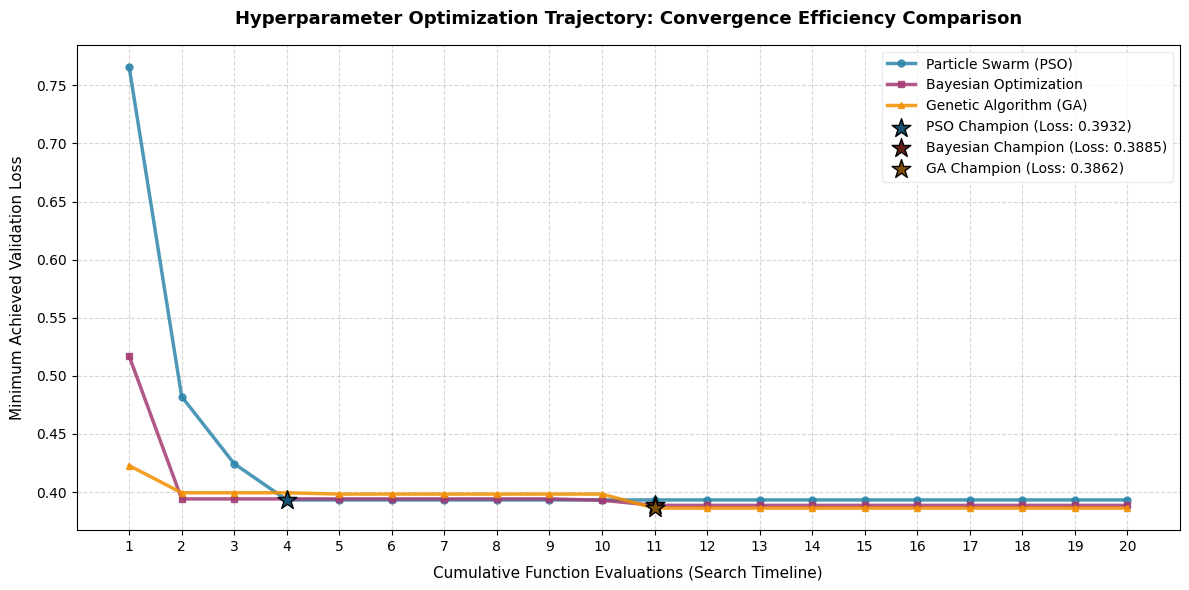

In [29]:
# ============================================================
# Cell 27: Optimization Loss Progression Comparison (All Algorithms)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

# Helper function to compute step-by-step optimization history trajectories
def calculate_running_best_loss(results, eval_key='eval_num'):
    # Sort chronologically to ensure proper timeline mapping
    sorted_res = sorted(results, key=lambda x: x[eval_key] if eval_key in x else x['eval_num'])

    evals = []
    running_loss = []
    current_best = float('inf')

    for r in sorted_res:
        step = r[eval_key] if eval_key in r else r['eval_num']
        loss = r['val_loss']
        if loss < current_best:
            current_best = loss
        evals.append(step)
        running_loss.append(current_best)

    return evals, running_loss

# 1. Compute individual tracking paths
pso_steps, pso_loss_track = calculate_running_best_loss(pso_all_results)
bayesian_steps, bayesian_loss_track = calculate_running_best_loss(bayesian_all_results)

# Map GA appropriately whether using 'Eval' or 'eval_num'
ga_eval_key = 'Eval' if len(ga_all_results) > 0 and 'Eval' in ga_all_results[0] else 'eval_num'
ga_steps, ga_loss_track = calculate_running_best_loss(ga_all_results, eval_key=ga_eval_key)

# 2. Plot baseline convergence lines
ax.plot(pso_steps, pso_loss_track, color='#2E86AB', linestyle='-', linewidth=2.5,
        marker='o', markersize=5, alpha=0.85, label='Particle Swarm (PSO)')

ax.plot(bayesian_steps, bayesian_loss_track, color='#A23B72', linestyle='-', linewidth=2.5,
        marker='s', markersize=5, alpha=0.85, label='Bayesian Optimization')

ax.plot(ga_steps, ga_loss_track, color='#F18F01', linestyle='-', linewidth=2.5,
        marker='^', markersize=5, alpha=0.85, label='Genetic Algorithm (GA)')

# 3. Mark absolute champion coordinate locations with prominent star highlights
ax.scatter(pso_best['eval_num'], pso_best['val_loss'], color='#1A5276',
           marker='*', s=200, zorder=5, edgecolors='black', label=f"PSO Champion (Loss: {pso_best['val_loss']:.4f})")

ax.scatter(bayesian_best['eval_num'], bayesian_best['val_loss'], color='#641E16',
           marker='*', s=200, zorder=5, edgecolors='black', label=f"Bayesian Champion (Loss: {bayesian_best['val_loss']:.4f})")

ga_best_step = ga_best['Eval'] if 'Eval' in ga_best else ga_best['eval_num']
ax.scatter(ga_best_step, ga_best['val_loss'], color='#7E5109',
           marker='*', s=200, zorder=5, edgecolors='black', label=f"GA Champion (Loss: {ga_best['val_loss']:.4f})")

# 4. Chart title settings and labeling configuration
ax.set_xlabel('Cumulative Function Evaluations (Search Timeline)', fontsize=11, labelpad=8)
ax.set_ylabel('Minimum Achieved Validation Loss', fontsize=11, labelpad=8)
ax.set_title('Hyperparameter Optimization Trajectory: Convergence Efficiency Comparison', fontsize=13, fontweight='bold', pad=15)

# Build flexible horizontal chart limit padding
max_evals = max(max(pso_steps), max(bayesian_steps), max(ga_steps))
ax.set_xlim([0, max_evals + 1])
ax.set_xticks(np.arange(1, max_evals + 1, step=max(1, max_evals // 20)))

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#e2e8f0', fontsize=10)

plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# Cell 29: Final Summary and Strategic Recommendations (Test Layout)
# ============================================================
import pandas as pd
from IPython.display import display

if 'df_test_summary' not in locals() or df_test_summary.empty:
    print("⚠️ df_test_summary not found. Please run the Test Summary matrix (Cell 24) first.")
else:
    print("=" * 110)
    print(f"🏁 FINAL SYNTHESIS: HYPERPARAMETER OPTIMIZATION TRUE TEST BENCHMARK SUMMARY")
    print("=" * 110)

    # 1. Identify category winners using your simplified lowercase keys
    algos_keys = ['PSO', 'Bayesian', 'Genetic Algorithm']

    best_loss_name = min(algos_keys, key=lambda k: df_test_summary.at['test loss', k])
    best_loss_val = df_test_summary.at['test loss', best_loss_name]

    best_time_name = min(algos_keys, key=lambda k: df_test_summary.at['total optimization time', k])
    best_time_val = df_test_summary.at['total optimization time', best_time_name]

    best_memory_name = min(algos_keys, key=lambda k: df_test_summary.at['peak operational gpu usage', k])
    best_memory_val = df_test_summary.at['peak operational gpu usage', best_memory_name]

    # Champion designation strictly following your objective
    overall_winner_algo = best_loss_name
    overall_winner_loss = best_loss_val
    overall_winner_f1 = df_test_summary.at['test f1', overall_winner_algo]

    # 2. Build structured dataframe with clean, minimal category headers
    summary_rows = [
        {"Evaluation Category": "test loss winner", "Benchmark Winner": best_loss_name.upper(), "Achieved Value": f"{best_loss_val:.4f}"},
        {"Evaluation Category": "total optimization time winner", "Benchmark Winner": best_time_name.upper(), "Achieved Value": f"{best_time_val:.2f}s"},
        {"Evaluation Category": "peak operational gpu usage winner", "Benchmark Winner": best_memory_name.upper(), "Achieved Value": f"{best_memory_val:.1f} MB"},
        {"Evaluation Category": "🏆 SYSTEM CHAMPION", "Benchmark Winner": overall_winner_algo.upper(), "Achieved Value": f"Loss: {overall_winner_loss:.4f} (F1: {overall_winner_f1:.4f})"}
    ]

    df_final_summary = pd.DataFrame(summary_rows)

    # 3. Apply background highlights to the row structures
    def highlight_winners(row):
        if row.name == 3:  # System champion row
            return ['background-color: #FFF3E0; color: #E65100; font-weight: bold;' for _ in row]
        return ['background-color: #F8F9FA; color: #212529;' for _ in row]

    display(df_final_summary.style.apply(highlight_winners, axis=1).hide(axis='index'))

    # 4. Standardized text summary reporting
    print("\n" + "=" * 60)
    print("🎯 ARCHITECTURAL INSIGHTS & RECOMMENDATIONS")
    print("=" * 60)
    print(f"   • test loss: {best_loss_name} achieved the lowest value ({best_loss_val:.4f}).")
    print(f"   • total optimization time: {best_time_name} finished in {best_time_val:.2f}s.")
    print(f"   • peak operational gpu usage: {best_memory_name} held the smallest footprint ({best_memory_val:.1f} MB).")
    print(f"\n 🚀 STRATEGIC DIRECTIVE:")
    print(f"   Based on empirical testing under computational constraints on this image classification space,")
    print(f"   utilize '{overall_winner_algo}' as the core hyperparameter optimization engine.")
    print("=" * 60)

🏁 FINAL SYNTHESIS: HYPERPARAMETER OPTIMIZATION TRUE TEST BENCHMARK SUMMARY


Evaluation Category,Benchmark Winner,Achieved Value
test loss winner,GENETIC ALGORITHM,0.3698
total optimization time winner,GENETIC ALGORITHM,2141.53s
peak operational gpu usage winner,PSO,1708.8 MB
🏆 SYSTEM CHAMPION,GENETIC ALGORITHM,Loss: 0.3698 (F1: 0.8438)



🎯 ARCHITECTURAL INSIGHTS & RECOMMENDATIONS
   • test loss: Genetic Algorithm achieved the lowest value (0.3698).
   • total optimization time: Genetic Algorithm finished in 2141.53s.
   • peak operational gpu usage: PSO held the smallest footprint (1708.8 MB).

 🚀 STRATEGIC DIRECTIVE:
   Based on empirical testing under computational constraints on this image classification space,
   utilize 'Genetic Algorithm' as the core hyperparameter optimization engine.
